In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
from scipy import signal
from scipy.signal import find_peaks
from scipy.signal import welch, find_peaks
from scipy.signal import butter, filtfilt
from scipy.stats import norm
from scipy.fft import fft
import scipy.signal as sig
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
def stock_finance(ticker='NVDA',periodo='2y'):
    stock=ticker
    df = yf.download(stock, period=periodo, interval="1d")
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df['Returns'] = df['Close'].pct_change().dropna()
    df["MA_10"] = df["Close"].rolling(10).mean()
    df["MA_20"] = df["Close"].rolling(20).mean()
    df["MA_50"]=df["Close"].rolling(50).mean()
    df['MA_100']=df['Close'].rolling(100).mean()
    df["Volatility"] = df["Returns"].rolling(20).std()
    df["Cumulative_Returns"] = (1 + df["Returns"]).cumprod()
    df["Volume_Norm"] = df["Volume"] / df["Volume"].max()
    df['Stock']=stock
    df["BB_Middle"] = df["Close"].rolling(20).mean()
    df["BB_Std"] = df["Close"].rolling(20).std()
    df["BB_Upper"] = df["BB_Middle"] + 2 * df["BB_Std"]
    df["BB_Lower"] = df["BB_Middle"] - 2 * df["BB_Std"]
    return df

def compute_rsi(data, window=14):
    delta = data.diff()

    gain = (delta.where(delta > 0, 0)).rolling(window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window).mean()

    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))

    return rsi

def compute_macd(df, fast=12, slow=26, signal=9):
    ema_fast = df["Close"].ewm(span=fast, adjust=False).mean()
    ema_slow = df["Close"].ewm(span=slow, adjust=False).mean()

    macd = ema_fast - ema_slow
    signal_line = macd.ewm(span=signal, adjust=False).mean()
    hist = macd - signal_line

    return macd, signal_line, hist

In [3]:
df=stock_finance(ticker='NVDA',periodo='2y')
df["MACD"], df["MACD_Signal"], df["MACD_Hist"] = compute_macd(df)
df["RSI"] = compute_rsi(df["Close"], 14)
df["Buy_Signal"] = (df["RSI"] < 30) & (df["Close"] < df["BB_Lower"])
df["Sell_Signal"] = (df["RSI"] > 70) & (df["Close"] > df["BB_Upper"])

[*********************100%***********************]  1 of 1 completed


In [4]:
features = [
    'Close',
    'High',
    'Low',
    'Open',
    'Volume',
    'Returns',
    'MA_10',
    'MA_20',
    'MA_50',
    'MA_100',
    'Volatility',
    'Cumulative_Returns',
    'Volume_Norm',
    'BB_Middle',
    'BB_Std',
    'BB_Upper',
    'BB_Lower',
    'MACD',
    'MACD_Signal',
    'MACD_Hist',
    'RSI'
]

# **PCA**

In [ ]:
from sklearn.preprocessing import StandardScaler

X = df[features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()

# Ver cuanta información explica por cada componente
X_pca = pca.fit_transform(X_scaled)

import pandas as pd

loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=features
)

loadings[['PC1', 'PC2', 'PC3']]


var_exp = pd.DataFrame({
    "PC": range(1, len(pca.explained_variance_ratio_) + 1),
    "Varianza": pca.explained_variance_ratio_,
    "Acumulada": np.cumsum(pca.explained_variance_ratio_)
})

var_exp

,PC,Varianza,Acumulada
0,1,6.024459e-01,0.602446
1,2,1.518808e-01,0.754327
2,3,7.977282e-02,0.834099
3,4,6.796790e-02,0.902067
4,5,4.406047e-02,0.946128
5,6,3.313910e-02,0.979267
6,7,1.188922e-02,0.991156
7,8,5.531363e-03,0.996688
8,9,2.361187e-03,0.999049
9,10,5.452394e-04,0.999594


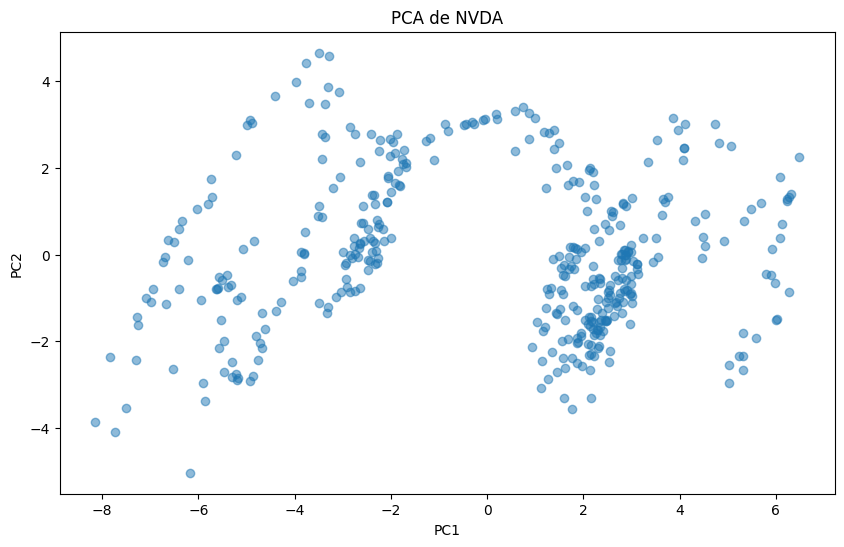

In [12]:
plt.figure(figsize=(10,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    alpha=0.5
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA de NVDA')
plt.show()

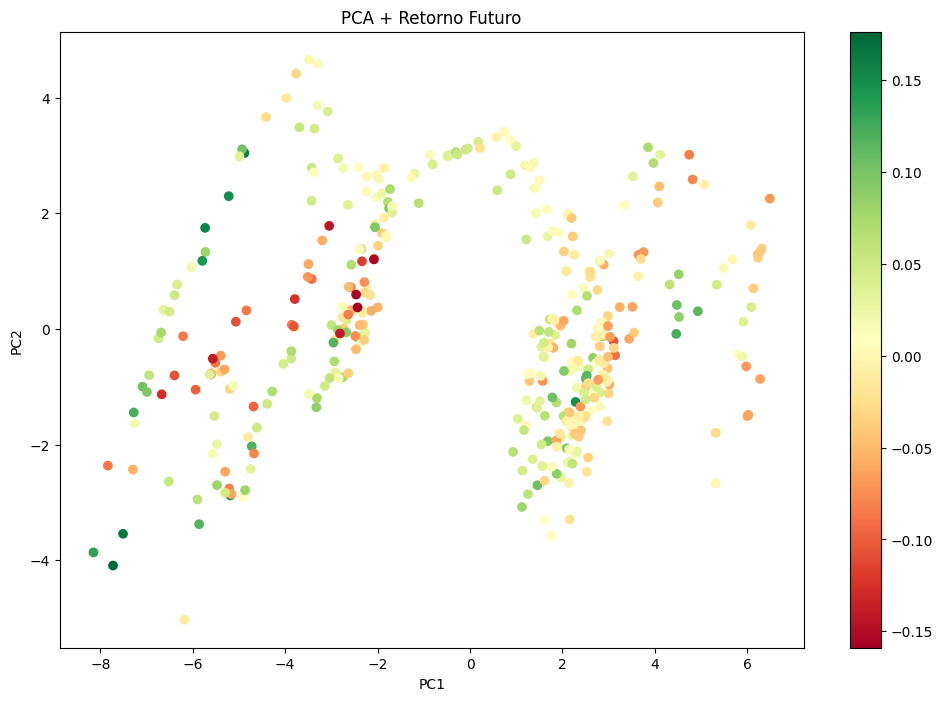

In [13]:
df['FutureReturn_5d'] = (
    df['Close'].shift(-5) / df['Close'] - 1
)

plt.figure(figsize=(12,8))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df.loc[X.index, 'FutureReturn_5d'],
    cmap='RdYlGn'
)

plt.colorbar(scatter)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA + Retorno Futuro')
plt.show()

In [14]:
print(var_exp.head(10))
print(loadings[['PC1','PC2','PC3']])

   PC  Varianza  Acumulada
0   1  0.602446   0.602446
1   2  0.151881   0.754327
2   3  0.079773   0.834099
3   4  0.067968   0.902067
4   5  0.044060   0.946128
5   6  0.033139   0.979267
6   7  0.011889   0.991156
7   8  0.005531   0.996688
8   9  0.002361   0.999049
9  10  0.000545   0.999594
                         PC1       PC2       PC3
Close               0.278952  0.021310  0.051759
High                0.278649  0.009203  0.072975
Low                 0.279486  0.025937  0.037982
Open                0.278861  0.012764  0.060946
Volume             -0.154773 -0.217131  0.457177
Returns             0.002210  0.118411 -0.102249
MA_10               0.278110 -0.051727  0.060355
MA_20               0.274724 -0.111943  0.034653
MA_50               0.259062 -0.196502  0.016565
MA_100              0.233861 -0.220494  0.084638
Volatility         -0.181082 -0.149967  0.277523
Cumulative_Returns  0.278952  0.021310  0.051759
Volume_Norm        -0.154773 -0.217131  0.457177
BB_Middle        

In [15]:
print(loadings['PC1'].sort_values(key=abs, ascending=False))

Low                   0.279486
Cumulative_Returns    0.278952
Close                 0.278952
Open                  0.278861
High                  0.278649
MA_10                 0.278110
MA_20                 0.274724
BB_Middle             0.274724
BB_Upper              0.271860
BB_Lower              0.271038
MA_50                 0.259062
MA_100                0.233861
Volatility           -0.181082
Volume               -0.154773
Volume_Norm          -0.154773
MACD_Signal           0.129382
MACD                  0.120110
RSI                   0.038536
MACD_Hist            -0.005058
Returns               0.002210
BB_Std               -0.002013
Name: PC1, dtype: float64


In [16]:
print(loadings['PC2'].sort_values(key=abs, ascending=False))

RSI                   0.502371
MACD                  0.452456
MACD_Signal           0.361767
MACD_Hist             0.356866
MA_100               -0.220494
Volume_Norm          -0.217131
Volume               -0.217131
MA_50                -0.196502
Volatility           -0.149967
BB_Lower             -0.127193
Returns               0.118411
MA_20                -0.111943
BB_Middle            -0.111943
BB_Std                0.109895
BB_Upper             -0.093935
MA_10                -0.051727
Low                   0.025937
Cumulative_Returns    0.021310
Close                 0.021310
Open                  0.012764
High                  0.009203
Name: PC2, dtype: float64


In [17]:
print(loadings['PC3'].sort_values(key=abs, ascending=False))

BB_Std                0.615287
Volume_Norm           0.457177
Volume                0.457177
Volatility            0.277523
RSI                   0.150903
MACD                  0.141822
BB_Upper              0.129332
MACD_Signal           0.118557
Returns              -0.102249
MACD_Hist             0.096412
MA_100                0.084638
High                  0.072975
Open                  0.060946
MA_10                 0.060355
BB_Lower             -0.060349
Cumulative_Returns    0.051759
Close                 0.051759
Low                   0.037982
MA_20                 0.034653
BB_Middle             0.034653
MA_50                 0.016565
Name: PC3, dtype: float64


In [18]:
var_exp = pd.DataFrame({
    "Varianza": pca.explained_variance_ratio_,
    "Acumulada": pca.explained_variance_ratio_.cumsum()
})

print(var_exp.head(10))

   Varianza  Acumulada
0  0.602446   0.602446
1  0.151881   0.754327
2  0.079773   0.834099
3  0.067968   0.902067
4  0.044060   0.946128
5  0.033139   0.979267
6  0.011889   0.991156
7  0.005531   0.996688
8  0.002361   0.999049
9  0.000545   0.999594


In [19]:
print(var_exp.head(5))
print(loadings[['PC1','PC2','PC3']])

   Varianza  Acumulada
0  0.602446   0.602446
1  0.151881   0.754327
2  0.079773   0.834099
3  0.067968   0.902067
4  0.044060   0.946128
                         PC1       PC2       PC3
Close               0.278952  0.021310  0.051759
High                0.278649  0.009203  0.072975
Low                 0.279486  0.025937  0.037982
Open                0.278861  0.012764  0.060946
Volume             -0.154773 -0.217131  0.457177
Returns             0.002210  0.118411 -0.102249
MA_10               0.278110 -0.051727  0.060355
MA_20               0.274724 -0.111943  0.034653
MA_50               0.259062 -0.196502  0.016565
MA_100              0.233861 -0.220494  0.084638
Volatility         -0.181082 -0.149967  0.277523
Cumulative_Returns  0.278952  0.021310  0.051759
Volume_Norm        -0.154773 -0.217131  0.457177
BB_Middle           0.274724 -0.111943  0.034653
BB_Std             -0.002013  0.109895  0.615287
BB_Upper            0.271860 -0.093935  0.129332
BB_Lower            0.271038 

In [21]:
df_pca = pd.DataFrame(
    X_pca[:, :3],
    columns=['PC1','PC2','PC3'],
    index=X.index
)

df_pca['FutureReturn_5d'] = (
    df.loc[X.index, 'Close']
      .shift(-5)
      .div(df.loc[X.index, 'Close'])
      .sub(1)
)

df_pca.groupby(
    pd.qcut(df_pca['PC2'], 5)
)['FutureReturn_5d'].mean()

PC2
(-5.03, -1.529]     0.021163
(-1.529, -0.631]    0.007443
(-0.631, 0.174]    -0.004461
(0.174, 1.666]     -0.013596
(1.666, 4.656]      0.021241
Name: FutureReturn_5d, dtype: float64

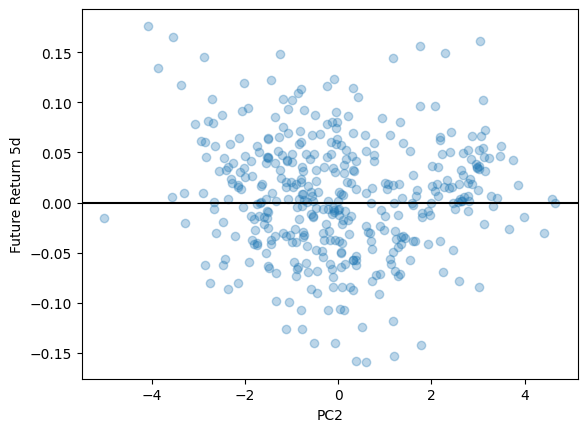

In [ ]:
plt.scatter(
    df_pca['PC2'],
    df_pca['FutureReturn_5d'],
    alpha=0.3
)

plt.axhline(0, color='black')
plt.xlabel("PC2")
plt.ylabel("Future Return 5d")
plt.show()

In [27]:
print(df_pca.groupby(
    pd.qcut(df_pca['PC3'], 5)
)['FutureReturn_5d'].mean())

PC3
(-2.533, -1.045]    0.016407
(-1.045, -0.578]    0.003590
(-0.578, 0.0313]    0.011605
(0.0313, 1.156]     0.002555
(1.156, 7.071]     -0.003054
Name: FutureReturn_5d, dtype: float64


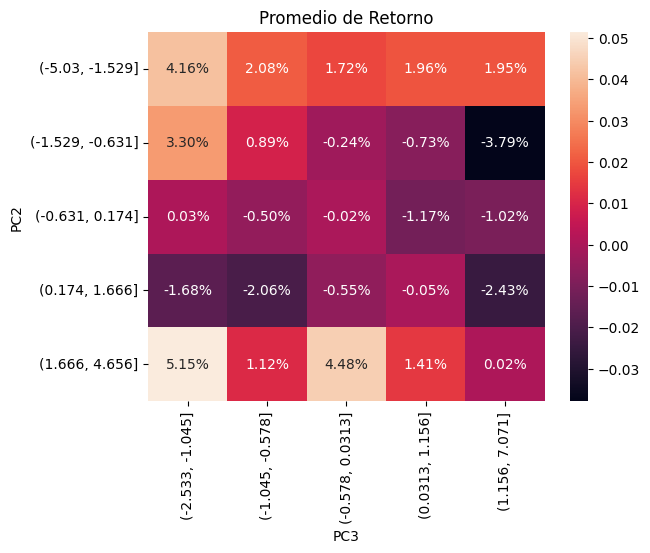

In [41]:
pivot = df_pca.pivot_table(
    values='FutureReturn_5d',
    index=pd.qcut(df_pca['PC2'],5),
    columns=pd.qcut(df_pca['PC3'],5),
    aggfunc='mean'
)

sns.heatmap(
    pivot,
    annot=True,
    fmt=".2%"
)
plt.title('Promedio de Retorno')
plt.show()

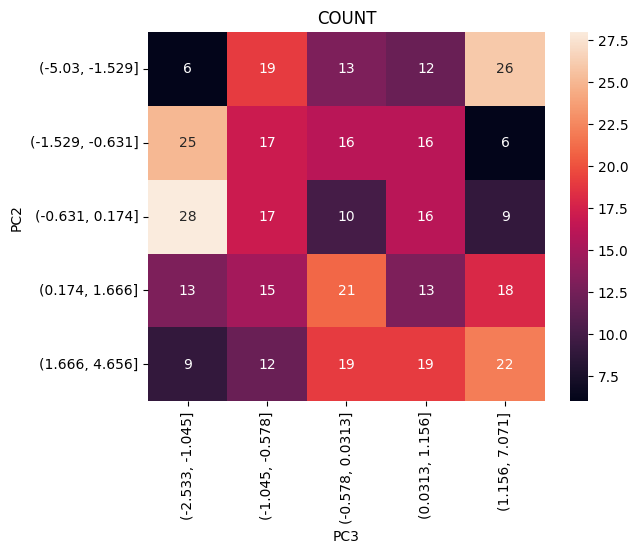

In [42]:
pivot_count = pd.pivot_table(
    df_pca,
    values='FutureReturn_5d',
    index=pd.qcut(df_pca['PC2'],5),
    columns=pd.qcut(df_pca['PC3'],5),
    aggfunc='count'
)

sns.heatmap(
    pivot_count,
    annot=True,
    fmt='d'
)
plt.title('COUNT')
plt.show()

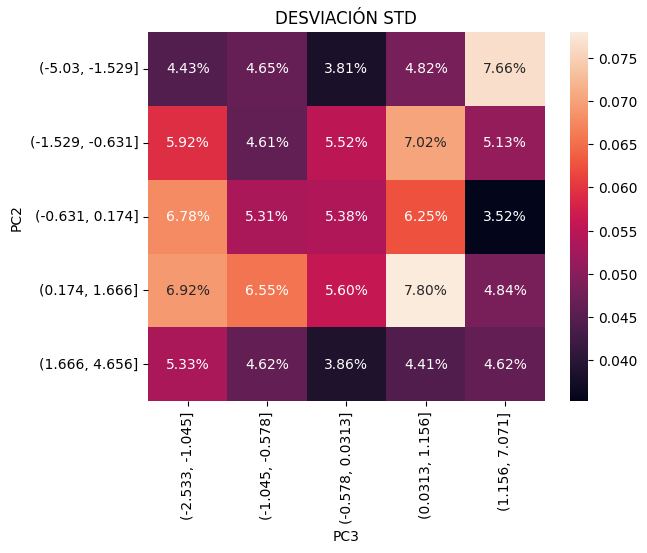

In [43]:
pivot_std = pd.pivot_table(
    df_pca,
    values='FutureReturn_5d',
    index=pd.qcut(df_pca['PC2'],5),
    columns=pd.qcut(df_pca['PC3'],5),
    aggfunc='std'
)

sns.heatmap(
    pivot_std,
    annot=True,
    fmt='.2%'
)
plt.title('DESVIACIÓN STD')
plt.show()

# **UMAP**

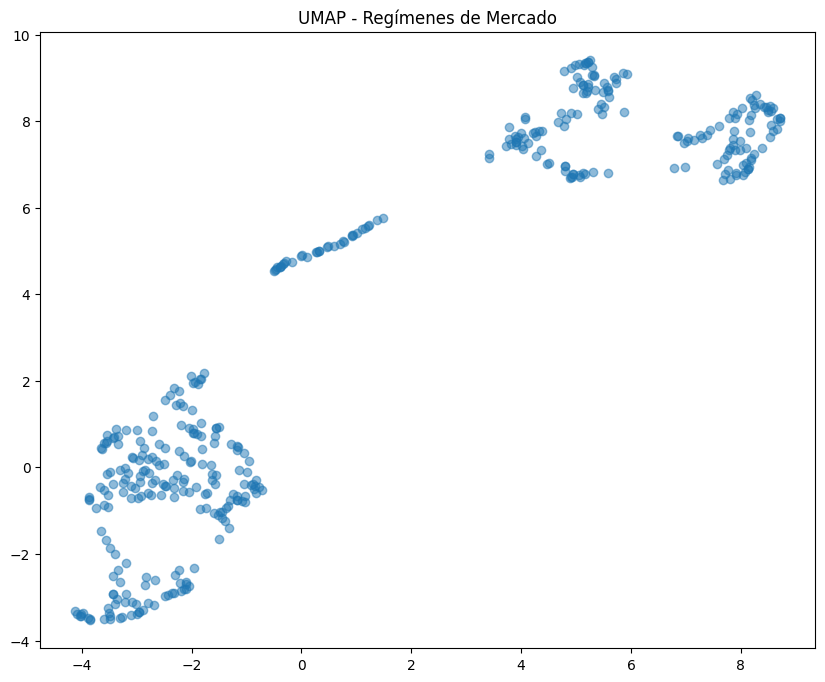

In [11]:
from sklearn.preprocessing import StandardScaler
import umap

X=df[features].dropna()
X_scaled=StandardScaler().fit_transform(X)

reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    random_state=42
)

embedding = reducer.fit_transform(X_scaled)


plt.figure(figsize=(10,8))

plt.scatter(
    embedding[:,0],
    embedding[:,1],
    alpha=0.5
)

plt.title("UMAP - Regímenes de Mercado")
plt.show()

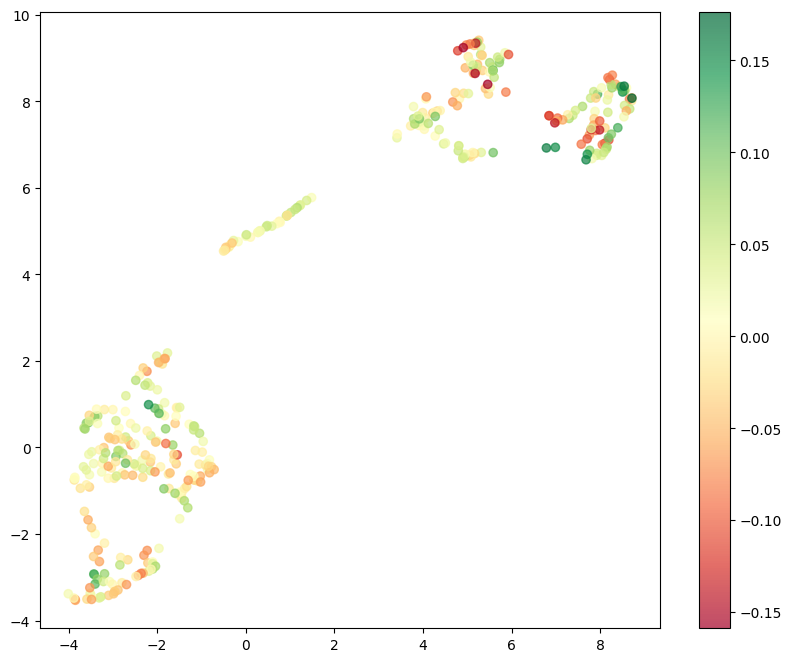

In [8]:
df_umap = pd.DataFrame(
    embedding,
    columns=['UMAP1','UMAP2'],
    index=X.index
)

df_umap['FutureReturn_5d'] = (
    df.loc[X.index,'Close']
      .shift(-5)
      .div(df.loc[X.index,'Close'])
      .sub(1)
)

plt.figure(figsize=(10,8))

scatter = plt.scatter(
    df_umap['UMAP1'],
    df_umap['UMAP2'],
    c=df_umap['FutureReturn_5d'],
    cmap='RdYlGn',
    alpha=0.7
)

plt.colorbar(scatter)
plt.show()

In [12]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

clusters = kmeans.fit_predict(embedding)

df_umap["Cluster"] = clusters

In [14]:
print(df_umap.groupby("Cluster")["FutureReturn_5d"].agg(
    ["count","mean","std"]
))

         count      mean       std
Cluster                           
0           89  0.000241  0.059945
1          151  0.008476  0.045199
2           71  0.011276  0.087138
3           51 -0.005374  0.054325
4           34  0.015958  0.028457


In [15]:
cluster_stats = (
    df_umap
    .join(df[features])
    .groupby("Cluster")[features]
    .mean()
)

print(cluster_stats)

              Close        High         Low        Open        Volume  \
Cluster                                                                 
0        139.741802  141.898499  137.474125  139.897385  2.164523e+08   
1        181.983214  184.527543  179.414686  182.104982  1.812415e+08   
2        116.276864  118.905730  113.201158  116.141403  2.965222e+08   
3        207.225460  210.723834  203.779432  207.540616  1.697519e+08   
4        172.366311  173.886345  170.172175  172.096083  1.582842e+08   

          Returns       MA_10       MA_20       MA_50      MA_100  ...  \
Cluster                                                            ...   
0        0.003660  137.840472  135.716489  129.710298  126.081448  ...   
1        0.001429  181.784664  182.294544  181.546412  175.001954  ...   
2       -0.001833  117.781200  120.033051  126.055523  131.292936  ...   
3       -0.000080  205.680089  201.152413  190.910597  185.912940  ...   
4        0.005211  168.382617  163.393398  1

In [21]:
from scipy.stats import ttest_ind

c4 = df_umap[df_umap.Cluster==4]["FutureReturn_5d"]
resto = df_umap[df_umap.Cluster!=4]["FutureReturn_5d"]

c4 = c4.dropna()
resto = resto.dropna()

# Prueba parametrica
t_stat, p_value = ttest_ind(
    c4,
    resto,
    equal_var=False
)

print("p-value", p_value)

# Prueba no parametrica
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(
    c4,
    resto,
    alternative='two-sided'
)

print("p-value:", p)

p-value 0.0653331606826222
p-value: 0.18989358287696811


In [22]:
print(c4.describe())
print(resto.describe())

count    34.000000
mean      0.015958
std       0.028457
min      -0.041057
25%       0.000003
50%       0.014195
75%       0.041882
max       0.066875
Name: FutureReturn_5d, dtype: float64
count    362.000000
mean       0.005049
std        0.060328
min       -0.158904
25%       -0.036026
50%        0.003454
75%        0.044557
max        0.176227
Name: FutureReturn_5d, dtype: float64


In [23]:
print("Cluster 4:", (c4 > 0).mean())
print("Resto:", (resto > 0).mean())

Cluster 4: 0.7352941176470589
Resto: 0.5414364640883977


# **NearestNeighbors**

In [3]:
import sys
import os

# Agregamos la carpeta Scripts al path de búsqueda de Python
ruta_scripts = r'D:\Github-Time\financial-time-series-lab\Scripts'
if ruta_scripts not in sys.path:
    sys.path.append(ruta_scripts)

# Ahora ya debería encontrarlo
from dowload_stocks import obtener_datos, agregar_indicadores

def ejecutar_analisis(ticker, periodo):
    print(f"--- Procesando {ticker} para el periodo {periodo} ---")
    
    # 1. Obtener datos
    df = obtener_datos(ticker, periodo)
    
    # 2. Agregar indicadores
    df = agregar_indicadores(df)
    
    return df

In [4]:
from arch import arch_model

df=ejecutar_analisis(ticker='SPY',periodo='2y')

df["Returns_Pct"] = df["Returns"] * 100
df_model = df["Returns_Pct"].dropna()

modelo_egarch_skewt = arch_model(
    df_model, mean="constant", vol="EGARCH",
    p=1, o=1, q=1, dist="skewt", rescale=False
)
res_skewt = modelo_egarch_skewt.fit(disp="off")

modelo_final = res_skewt
df["EGARCH_skewt_Vol"] = modelo_final.conditional_volatility

--- Procesando SPY para el periodo 2y ---


[*********************100%***********************]  1 of 1 completed


Régimen hoy: Lateral
10 días más parecidos: [datetime.date(2026, 6, 16) datetime.date(2024, 9, 18)
 datetime.date(2024, 8, 28) datetime.date(2025, 12, 30)
 datetime.date(2024, 9, 20) datetime.date(2025, 12, 16)
 datetime.date(2025, 12, 29) datetime.date(2024, 9, 17)
 datetime.date(2025, 11, 6) datetime.date(2024, 9, 25)]

Resumen por régimen:
Price          Returns         EGARCH_Vol            Mean            Skew  \
                  mean     std       mean     std    mean     std    mean   
Regimen_Nombre                                                              
Alcista         0.0023  0.0067     0.1173  0.0252  0.0022  0.0013  0.1382   
Bajista         0.0011  0.0209     0.2667  0.0735 -0.0024  0.0014  0.3241   
Lateral        -0.0010  0.0093     0.1486  0.0276  0.0003  0.0009 -0.8142   

Price                   
                   std  
Regimen_Nombre          
Alcista         0.5636  
Bajista         0.7576  
Lateral         0.6453  


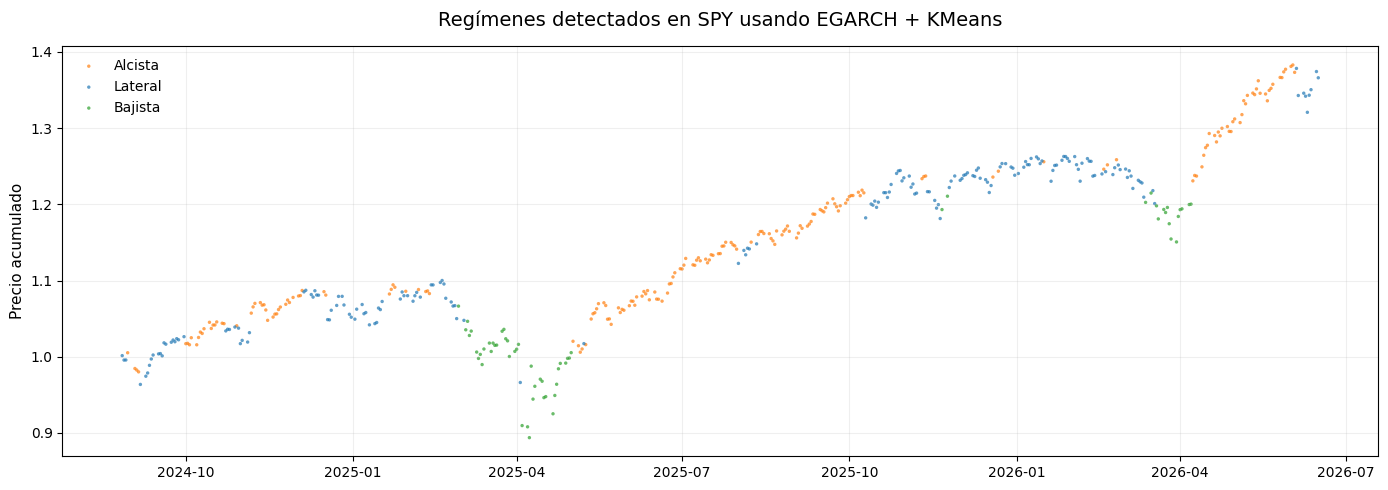

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from arch import arch_model
import warnings
warnings.filterwarnings('ignore')

class SPYRegimeDetector:
    def __init__(self, window=20, n_regimes=3, n_neighbors=10, auto_k=False):
        self.window = window
        self.n_regimes = n_regimes
        self.n_neighbors = n_neighbors
        self.auto_k = auto_k
        self.scaler = StandardScaler()
        self.kmeans = None
        self.knn = None
        self.features = ['Returns', 'EGARCH_Vol', 'Mean', 'Skew']
        self.regime_map = {}

    def _fit_egarch(self, returns):
        """Ajusta EGARCH(1,1) con skew-t. Retornos deben estar en %."""
        model = arch_model(
            returns * 100, mean='constant', vol='EGARCH',
            p=1, o=1, q=1, dist='skewt', rescale=False
        )
        res = model.fit(disp='off', show_warning=False)
        return res.conditional_volatility / 100 # vuelve a decimal

    def _create_features(self, df):
        """Genera features de régimen usando ventanas móviles + EGARCH."""
        df = df.copy()
        df['EGARCH_Vol'] = self._fit_egarch(df['Returns'].dropna())
        df['Vol_Rolling'] = df['Returns'].rolling(self.window).std()
        df['Mean'] = df['Returns'].rolling(self.window).mean()
        df['Skew'] = df['Returns'].rolling(self.window).skew()
        return df.dropna()

    def _select_k(self, X_scaled, k_range=range(2, 7)):
        """Elige k óptimo por silhouette. Si auto_k=False, usa self.n_regimes."""
        if not self.auto_k:
            return self.n_regimes
        scores = []
        for k in k_range:
            km = KMeans(n_clusters=k, n_init=20, random_state=42)
            labels = km.fit_predict(X_scaled)
            scores.append(silhouette_score(X_scaled, labels))
        return k_range[np.argmax(scores)]

    def _name_regimes(self, df):
        """Mapea 0/1/2 a Bajista/Lateral/Alcista según Mean de 20d."""
        resumen = df.groupby('Regimen')['Mean'].mean().sort_values()
        names = ['Bajista', 'Lateral', 'Alcista']
        if len(resumen) == 2: names = ['Bajista', 'Alcista']
        if len(resumen) >= 3: names = ['Bajista', 'Lateral', 'Alcista']
        self.regime_map = {k: names[i] for i, k in enumerate(resumen.index)}
        return df['Regimen'].map(self.regime_map)

    def fit(self, df):
        """Entrena todo: EGARCH + KMeans + KNN."""
        df_feat = self._create_features(df)
        X = df_feat[self.features].values
        X_scaled = self.scaler.fit_transform(X)

        # 1. KMeans
        k = self._select_k(X_scaled)
        self.kmeans = KMeans(n_clusters=k, n_init=20, random_state=42)
        df_feat['Regimen'] = self.kmeans.fit_predict(X_scaled)
        df_feat['Regimen_Nombre'] = self._name_regimes(df_feat)

        # 2. KNN para inferencia rápida
        self.knn = NearestNeighborsVa 

### **Código mejorado y profesional**

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from arch import arch_model
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

class SPYRegimeDetector:
    def __init__(self, n_regimes=3, window=20, k_neighbors=10):
        self.n_regimes = n_regimes
        self.window = window
        self.k_neighbors = k_neighbors
        self.scaler = StandardScaler()
        self.kmeans = KMeans(n_clusters=n_regimes, n_init=20, random_state=42)
        self.knn = NearestNeighbors(n_neighbors=k_neighbors)
        self.regime_labels = {}

    def _fit_egarch(self, returns):
        """Ajusta EGARCH-skewt y devuelve vol condicional anualizada"""
        model = arch_model(
            returns * 100, # arch trabaja mejor en %
            mean="Constant", vol="EGARCH", p=1, o=1, q=1,
            dist="skewt", rescale=False
        )
        res = model.fit(disp="off", show_warning=False)
        # Vol condicional diaria -> anualizada
        return res.conditional_volatility / 100 * np.sqrt(252)

    def _create_features(self, df):
        """Crea features de régimen: EGARCH vol, drift, skew"""
        df = df.copy()
        df['EGARCH_Vol'] = self._fit_egarch(df['Returns'].dropna())
        df['Mean'] = df['Returns'].rolling(self.window).mean()
        df['Skew'] = df['Returns'].rolling(self.window).skew()
        return df.dropna()

    def _label_regimes(self, df):
        """Asigna nombres a clusters según media de retornos"""
        regime_stats = df.groupby('Regimen')['Mean'].mean().sort_values()
        labels = {regime_stats.index[0]: 'Bajista',
                  regime_stats.index[1]: 'Lateral',
                  regime_stats.index[2]: 'Alcista'}
        return labels

    def fit(self, df):
        """Entrena el detector de regímenes"""
        df = df.dropna(subset=['Returns']).copy()
        df = self._create_features(df)

        self.features = ['Returns', 'EGARCH_Vol', 'Mean', 'Skew']
        X = df[self.features].values
        self.X_scaled = self.scaler.fit_transform(X)

        df['Regimen'] = self.kmeans.fit_predict(self.X_scaled)
        self.knn.fit(self.X_scaled)

        self.regime_labels = self._label_regimes(df)
        df['Regimen_Nombre'] = df['Regimen'].map(self.regime_labels)

        self.df = df
        return self

    def predict_today(self):
        """Clasifica el último día usando KNN"""
        dist, idx = self.knn.kneighbors(self.X_scaled[-1].reshape(1, -1))
        regime_id = self.df['Regimen'].iloc[idx[0]].mode()[0]
        return self.regime_labels[regime_id], idx[0]

    def plot_regimes(self):
        """Plot profesional de regímenes"""
        df = self.df.copy()
        df['Close'] = (1 + df['Returns']).cumprod()

        colores = {'Alcista': '#ff7f0e', 'Lateral': '#1f77b4', 'Bajista': '#2ca02c'}

        fig, ax = plt.subplots(figsize=(14, 5))
        for nombre, color in colores.items():
            mask = df['Regimen_Nombre'] == nombre
            ax.scatter(df.index[mask], df['Close'][mask], s=6, c=color,
                       label=nombre, alpha=0.7, edgecolors='none')

        ax.set_title('Regímenes detectados en SPY usando EGARCH + KMeans', fontsize=14, pad=15)
        ax.set_ylabel('Precio acumulado', fontsize=11)
        ax.legend(frameon=False, loc='upper left')
        ax.grid(alpha=0.2)
        plt.tight_layout()
        plt.show()

    def summary(self):
        """Resumen estadístico por régimen"""
        stats = self.df.groupby('Regimen_Nombre')[self.features].agg(['mean', 'std'])
        return stats.round(4)

# ---------------- USO ----------------
detector = SPYRegimeDetector(n_regimes=3, window=20)
detector.fit(df)

regimen_hoy, idx_vecinos = detector.predict_today()
print(f"Régimen hoy: {regimen_hoy}")
print(f"10 días más parecidos: {detector.df.index[idx_vecinos].date}")

print("\nResumen por régimen:")
print(detector.summary())

detector.plot_regimes()

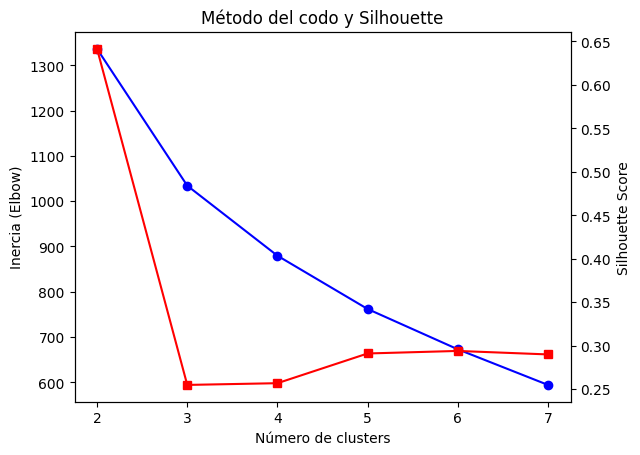

In [62]:
from sklearn.metrics import silhouette_score

inertias = []
sil_scores = []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel('Número de clusters')
ax1.set_ylabel('Inercia (Elbow)')
ax2.plot(K_range, sil_scores, 'rs-')
ax2.set_ylabel('Silhouette Score')
plt.title('Método del codo y Silhouette')
plt.show()

    Inercia  Silhouette  Davies_Bouldin  Calinski_Harabasz
k                                                         
2  1336.346       0.641           0.754            158.824
3  1034.306       0.255           1.241            167.933
4   879.637       0.257           1.207            157.605
5   761.945       0.291           1.088            153.419
6   672.933       0.294           0.931            150.458
7   594.273       0.290           0.922            151.476


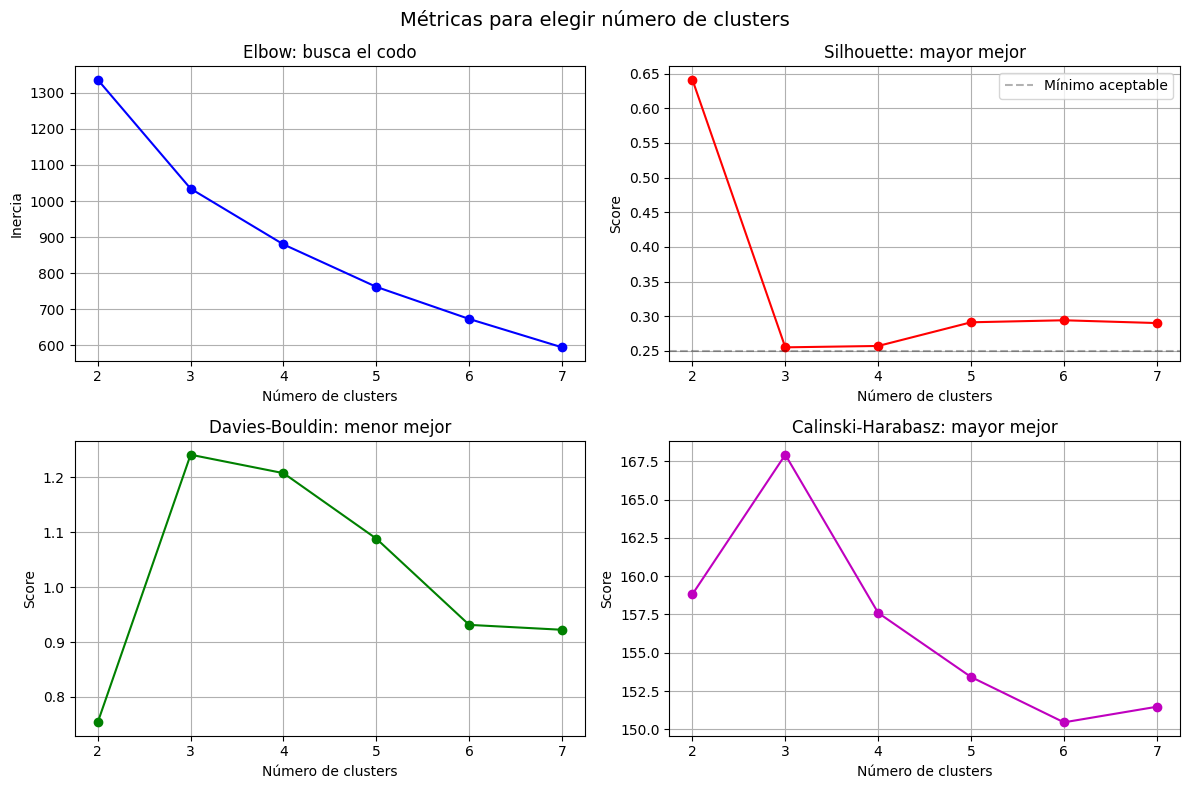


Sugerencias: Silhouette=2, Davies-Bouldin=2, Calinski-Harabasz=3


In [63]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import KMeans

def evaluar_k(X_scaled, k_range=range(2, 9)):
    resultados = []
    
    for k in k_range:
        km = KMeans(n_clusters=k, n_init=20, random_state=42)
        labels = km.fit_predict(X_scaled)
        
        resultados.append({
            'k': k,
            'Inercia': km.inertia_,
            'Silhouette': silhouette_score(X_scaled, labels),
            'Davies_Bouldin': davies_bouldin_score(X_scaled, labels),  # menor mejor
            'Calinski_Harabasz': calinski_harabasz_score(X_scaled, labels)  # mayor mejor
        })
    
    df_metrics = pd.DataFrame(resultados).set_index('k')
    print(df_metrics.round(3))
    
    # Plot 2x2
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle('Métricas para elegir número de clusters', fontsize=14)
    
    # 1. Elbow
    axes[0,0].plot(df_metrics.index, df_metrics['Inercia'], 'bo-')
    axes[0,0].set_title('Elbow: busca el codo')
    axes[0,0].set_ylabel('Inercia')
    axes[0,0].grid(True)
    
    # 2. Silhouette - mayor mejor
    axes[0,1].plot(df_metrics.index, df_metrics['Silhouette'], 'ro-')
    axes[0,1].set_title('Silhouette: mayor mejor')
    axes[0,1].set_ylabel('Score')
    axes[0,1].axhline(0.25, c='k', ls='--', alpha=0.3, label='Mínimo aceptable')
    axes[0,1].grid(True)
    axes[0,1].legend()
    
    # 3. Davies-Bouldin - menor mejor
    axes[1,0].plot(df_metrics.index, df_metrics['Davies_Bouldin'], 'go-')
    axes[1,0].set_title('Davies-Bouldin: menor mejor')
    axes[1,0].set_ylabel('Score')
    axes[1,0].grid(True)
    
    # 4. Calinski-Harabasz - mayor mejor
    axes[1,1].plot(df_metrics.index, df_metrics['Calinski_Harabasz'], 'mo-')
    axes[1,1].set_title('Calinski-Harabasz: mayor mejor')
    axes[1,1].set_ylabel('Score')
    axes[1,1].grid(True)
    
    for ax in axes.flat:
        ax.set_xlabel('Número de clusters')
    
    plt.tight_layout()
    plt.show()
    
    # Sugerencia automática
    k_sil = df_metrics['Silhouette'].idxmax()
    k_db = df_metrics['Davies_Bouldin'].idxmin()
    k_ch = df_metrics['Calinski_Harabasz'].idxmax()
    print(f"\nSugerencias: Silhouette={k_sil}, Davies-Bouldin={k_db}, Calinski-Harabasz={k_ch}")
    
    return df_metrics

# Uso:
df_metrics = evaluar_k(X_scaled, range(2, 8))

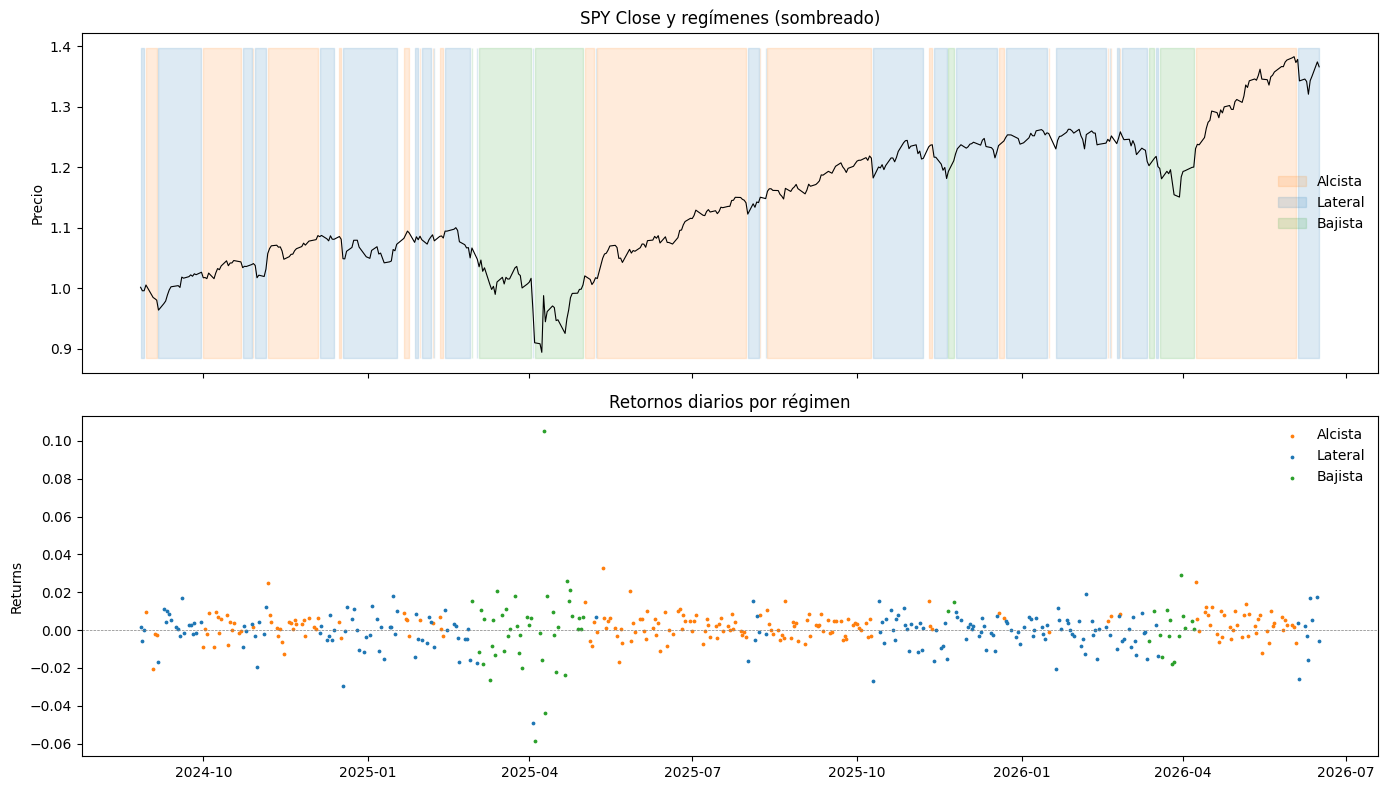

In [64]:
# Serie temporal de regímenes con precio y retornos
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14,8), sharex=True)

# Usa detector.df, no df
df_plot = detector.df.copy()
df_plot['Close'] = (1 + df_plot['Returns']).cumprod()

# Colores por nombre, no por número
colors = {'Alcista': '#ff7f0e', 'Lateral': '#1f77b4', 'Bajista': '#2ca02c'}

for nombre, color in colors.items():
    mask = df_plot['Regimen_Nombre'] == nombre
    ax1.fill_between(df_plot.index, df_plot['Close'].min()*0.99, df_plot['Close'].max()*1.01,
                     where=mask, color=color, alpha=0.15, label=nombre)

ax1.plot(df_plot.index, df_plot['Close'], color='black', lw=0.8)
ax1.set_title('SPY Close y regímenes (sombreado)')
ax1.set_ylabel('Precio')
ax1.legend(frameon=False)

# Retornos diarios coloreados por régimen
for nombre, color in colors.items():
    mask = df_plot['Regimen_Nombre'] == nombre
    ax2.scatter(df_plot.index[mask], df_plot['Returns'][mask], s=3, c=color, label=nombre)

ax2.axhline(0, color='gray', ls='--', lw=0.5)
ax2.set_title('Retornos diarios por régimen')
ax2.set_ylabel('Returns')
ax2.legend(frameon=False)
plt.tight_layout()
plt.show()

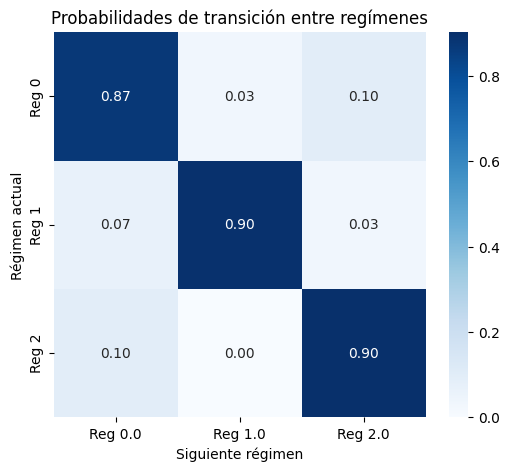

In [65]:
# 2. Matriz de transición entre regímenes

from pandas import crosstab

# Calcular transiciones
df_plot['Regimen_next'] = df_plot['Regimen'].shift(-1)
trans_mat = crosstab(df_plot['Regimen'], df_plot['Regimen_next'], normalize='index')

# Heatmap
import seaborn as sns
plt.figure(figsize=(6,5))
sns.heatmap(trans_mat, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[f'Reg {i}' for i in trans_mat.columns],
            yticklabels=[f'Reg {i}' for i in trans_mat.index])
plt.title('Probabilidades de transición entre regímenes')
plt.xlabel('Siguiente régimen')
plt.ylabel('Régimen actual')
plt.show()

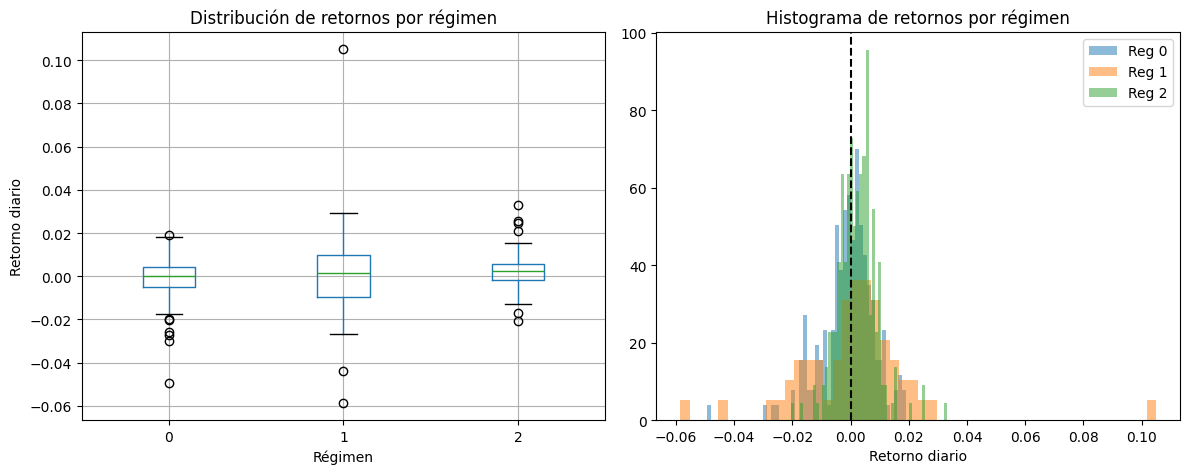

In [66]:
# 3. Distribución condicional de retornos por régimen (boxplot + histograma)

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Boxplot
df_plot.boxplot(column='Returns', by='Regimen', ax=axes[0])
axes[0].set_title('Distribución de retornos por régimen')
axes[0].set_xlabel('Régimen')
axes[0].set_ylabel('Retorno diario')

# Histograma overlay
for r in sorted(df_plot['Regimen'].unique()):
    axes[1].hist(df_plot.loc[df_plot['Regimen']==r, 'Returns'], bins=50, alpha=0.5,
                 label=f'Reg {r}', density=True)
axes[1].axvline(0, color='black', ls='--')
axes[1].legend()
axes[1].set_title('Histograma de retornos por régimen')
axes[1].set_xlabel('Retorno diario')
plt.suptitle('')
plt.tight_layout()
plt.show()

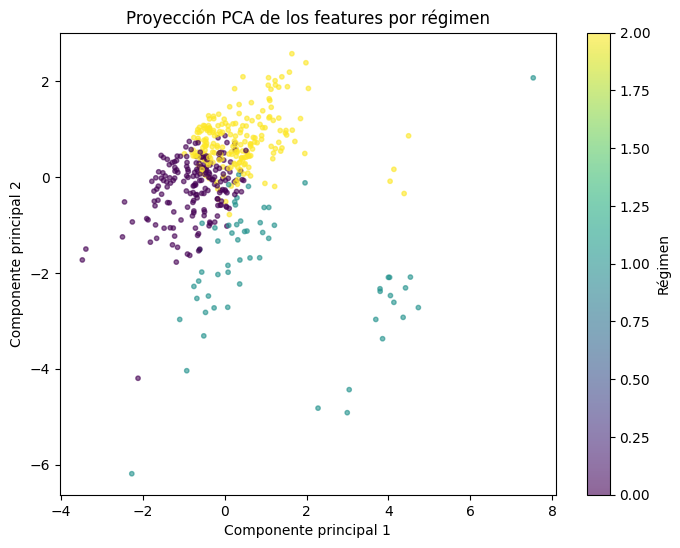

In [69]:
# 4. Visualización de clusters (PCA o t‑SNE)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=df_plot['Regimen'], cmap='viridis', s=10, alpha=0.6)
plt.colorbar(scatter, label='Régimen')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.title('Proyección PCA de los features por régimen')
plt.show()

In [70]:
# Varianza explicada
print(f"PC1 explica: {pca.explained_variance_ratio_[0]:.1%}")
print(f"PC2 explica: {pca.explained_variance_ratio_[1]:.1%}")

# Qué features pesan más en cada PC
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=['Returns', 'EGARCH_Vol', 'Mean', 'Skew']
)
print(loadings.round(2))

PC1 explica: 37.3%
PC2 explica: 32.2%
             PC1   PC2
Returns     0.37  0.44
EGARCH_Vol  0.60 -0.48
Mean        0.12  0.76
Skew        0.69  0.04


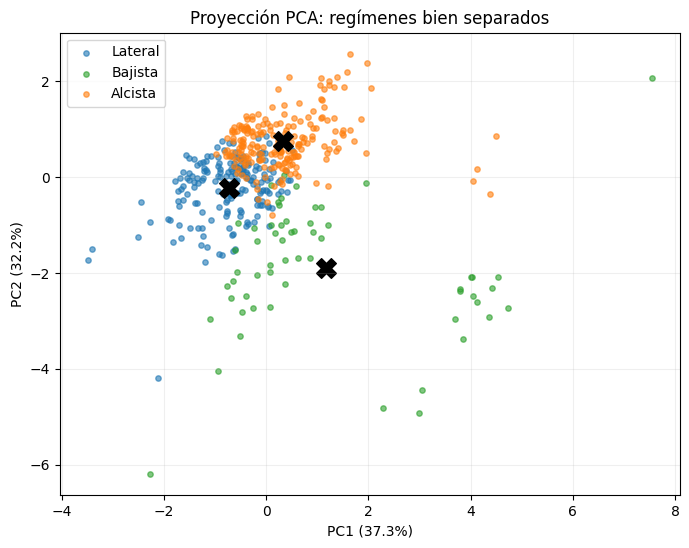

In [71]:
colores = {0: '#1f77b4', 1: '#2ca02c', 2: '#ff7f0e'} # Lateral, Bajista, Alcista
labels = {0: 'Lateral', 1: 'Bajista', 2: 'Alcista'}

plt.figure(figsize=(8,6))
for reg in [0, 1, 2]:
    mask = df_plot['Regimen'] == reg
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colores[reg], s=15, alpha=0.6, label=labels[reg])
for reg in [0, 1, 2]:
    mask = df_plot['Regimen'] == reg
    centroid = X_pca[mask].mean(axis=0)
    plt.scatter(centroid[0], centroid[1], c='black', s=200, marker='X')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.legend()
plt.title('Proyección PCA: regímenes bien separados')
plt.grid(alpha=0.2)
plt.show()


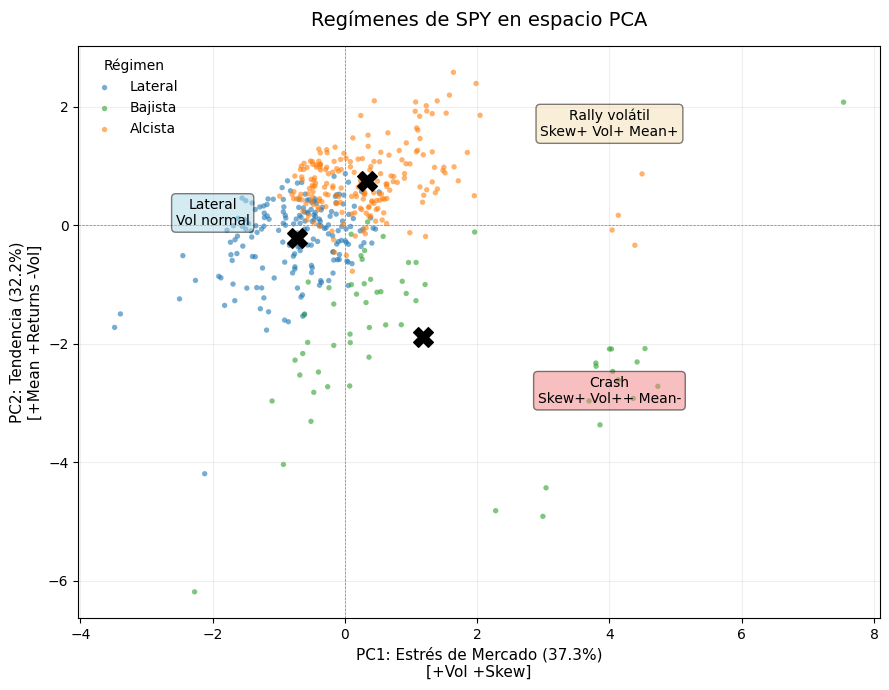

In [72]:
import matplotlib.pyplot as plt
import pandas as pd

# Asumo que ya tienes: X_pca, df_plot, pca
colores = {0: '#1f77b4', 1: '#2ca02c', 2: '#ff7f0e'} # Lateral, Bajista, Alcista
labels = {0: 'Lateral', 1: 'Bajista', 2: 'Alcista'}

fig, ax = plt.subplots(figsize=(9, 7))

for reg in [0, 1, 2]:
    mask = df_plot['Regimen'] == reg
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colores[reg], s=15, alpha=0.6, label=labels[reg], edgecolors='none')

    # Centroide
    centroid = X_pca[mask].mean(axis=0)
    ax.scatter(centroid[0], centroid[1], c='black', s=200, marker='X', zorder=5)

ax.set_xlabel(f'PC1: Estrés de Mercado (37.3%)\n[+Vol +Skew]', fontsize=11)
ax.set_ylabel(f'PC2: Tendencia (32.2%)\n[+Mean +Returns -Vol]', fontsize=11)
ax.set_title('Regímenes de SPY en espacio PCA', fontsize=14, pad=15)
ax.legend(frameon=False, title='Régimen')
ax.grid(alpha=0.2)
ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.axvline(0, color='gray', lw=0.5, ls='--')

# Anotaciones para interpretar cuadrantes
ax.text(4, 1.5, 'Rally volátil\nSkew+ Vol+ Mean+', ha='center',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.text(4, -3, 'Crash\nSkew+ Vol++ Mean-', ha='center',
        bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))
ax.text(-2, 0, 'Lateral\nVol normal', ha='center',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.show()

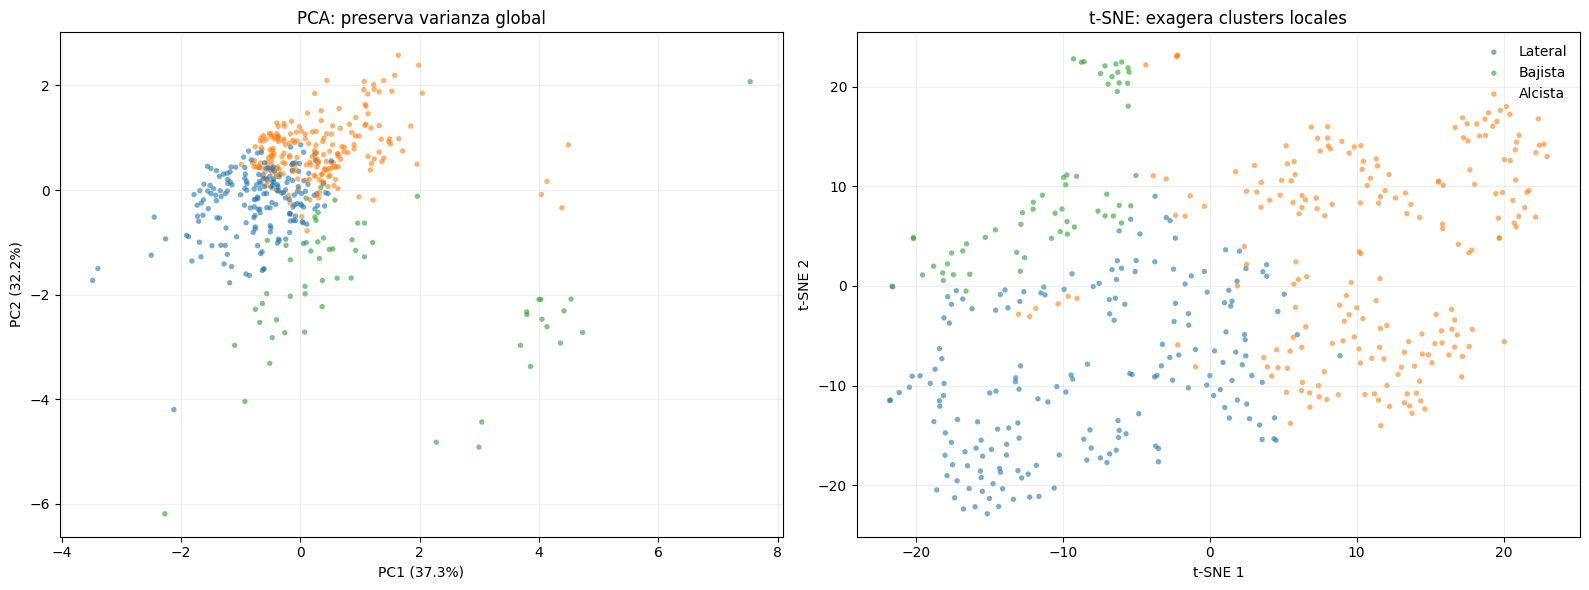

In [73]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# 1. t-SNE: ojo que es lento, usa solo si tienes <10k filas
# perplexity ≈ n_neighbors que esperarías. 30-50 va bien para datos diarios
tsne = TSNE(
    n_components=2,
    perplexity=30, # balance entre local y global. Prueba 20-50
    max_iter=1000, # más iter = mejor pero más lento
    random_state=42, # reproducible
    learning_rate='auto',
    init='pca' # inicia con PCA para que sea estable
)

X_tsne = tsne.fit_transform(X_scaled) # Usa el mismo X_scaled de antes

# 2. Plot igual que PCA pero con t-SNE
colores = {0: '#1f77b4', 1: '#2ca02c', 2: '#ff7f0e'} # Lateral, Bajista, Alcista
labels = {0: 'Lateral', 1: 'Bajista', 2: 'Alcista'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# PCA para comparar
ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=df_plot['Regimen'].map(colores),
            s=15, alpha=0.6, edgecolors='none')
ax1.set_title('PCA: preserva varianza global', fontsize=12)
ax1.set_xlabel(f'PC1 (37.3%)')
ax1.set_ylabel(f'PC2 (32.2%)')
ax1.grid(alpha=0.2)

# t-SNE
for reg in [0, 1, 2]:
    mask = df_plot['Regimen'] == reg
    ax2.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                c=colores[reg], s=15, alpha=0.6, label=labels[reg], edgecolors='none')

ax2.set_title('t-SNE: exagera clusters locales', fontsize=12)
ax2.set_xlabel('t-SNE 1')
ax2.set_ylabel('t-SNE 2')
ax2.legend(frameon=False)
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [74]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

sil = silhouette_score(X_scaled, df_plot['Regimen'])
db = davies_bouldin_score(X_scaled, df_plot['Regimen'])

print(f"Silhouette: {sil:.3f} | >0.25 es bueno en finanzas")
print(f"Davies-Bouldin: {db:.3f} | <1.0 es bueno")

# Para comparar: qué pasa si fuerzas k=4
from sklearn.cluster import KMeans
km4 = KMeans(n_clusters=4, n_init=20, random_state=42).fit(X_scaled)
print(f"Silhouette k=4: {silhouette_score(X_scaled, km4.labels_):.3f}")

Silhouette: 0.193 | >0.25 es bueno en finanzas
Davies-Bouldin: 1.444 | <1.0 es bueno
Silhouette k=4: 0.257


In [75]:
# Si quieres ver si Bajista se parte en 2 clusters
tsne_local = TSNE(perplexity=15, random_state=42).fit_transform(X_scaled) # más local
tsne_global = TSNE(perplexity=50, random_state=42).fit_transform(X_scaled) # más global

           Buy&Hold  Estrategia
Ret Anual     0.190       0.007
Vol Anual     0.170       0.127
Sharpe        1.106       0.115
Max DD       -0.188      -0.147


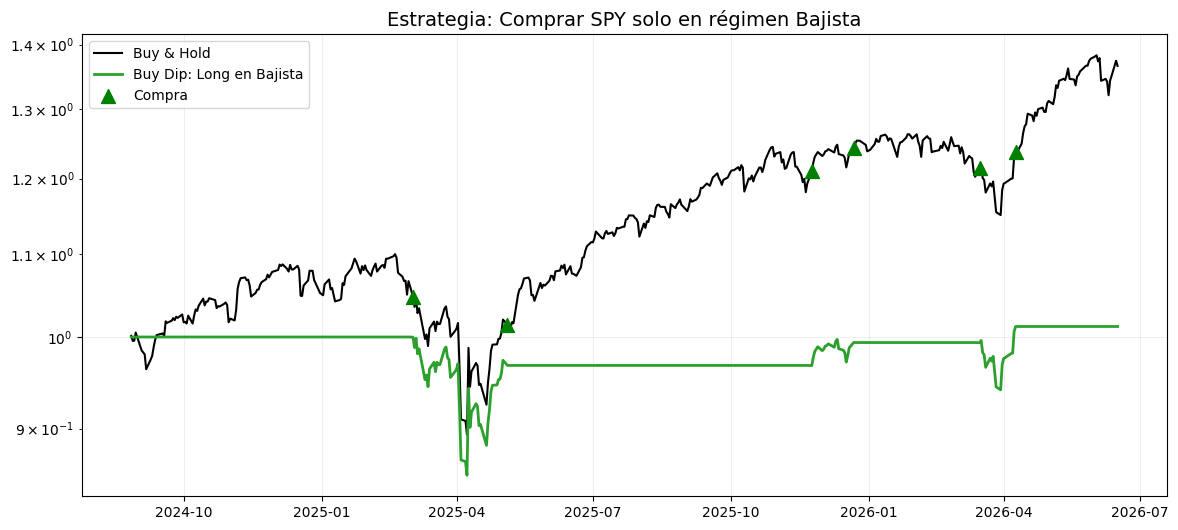

In [76]:
def metricas_fix(df):
    bh = df['Returns'].dropna()
    est = df['Ret_Estrategia_Neto'].dropna()

    # Sharpe sin asumir ret positivo
    def sharpe(x):
        if x.std() == 0: return 0
        return x.mean() / x.std() * np.sqrt(252)

    def cagr(x):
        if (1+x).prod() <= 0: return -1
        return (1+x).prod() ** (252/len(x)) - 1

    def max_dd(x):
        cum = (1 + x).cumprod()
        return ((cum / cum.cummax()) - 1).min()

    stats = pd.DataFrame({
        'Buy&Hold': [cagr(bh), bh.std()*np.sqrt(252), sharpe(bh), max_dd(bh)],
        'Estrategia': [cagr(est), est.std()*np.sqrt(252), sharpe(est), max_dd(est)]
    }, index=['Ret Anual', 'Vol Anual', 'Sharpe', 'Max DD'])
    return stats.round(3)

def backtest_buy_the_dip(df_reg, hold_months=12, costo_bps=2):
    """
    Compra solo cuando régimen = Bajista. Mantiene N meses o hasta que cambie a Alcista.
    """
    df = df_reg.copy()
    df['Signal'] = df['Regimen_Nombre'].shift(1) # régimen de ayer

    # 1. Marca entrada: primer día que aparece Bajista después de no estarlo
    df['Bajista'] = df['Signal'] == 'Bajista'
    df['Entry'] = (df['Bajista']) & (~df['Bajista'].shift(1).fillna(False))

    # 2. Mantienes posición por hold_months días o hasta que aparezca Alcista
    df['Position'] = 0
    in_position = False
    days_held = 0

    for i in range(len(df)):
        if df['Entry'].iloc[i] and not in_position:
            in_position = True
            days_held = 0
            df.iloc[i, df.columns.get_loc('Position')] = 1

        elif in_position:
            days_held += 1
            df.iloc[i, df.columns.get_loc('Position')] = 1

            # Salida: por tiempo o porque ya cambió a Alcista
            if days_held >= hold_months * 21 or df['Signal'].iloc[i] == 'Alcista':
                in_position = False
                df.iloc[i, df.columns.get_loc('Position')] = 0 # sales al cierre de hoy

    # 3. Retornos y costos
    df['Ret_Estrategia'] = df['Position'].shift(1).fillna(0) * df['Returns']
    df['Trade'] = df['Position'].diff().abs().fillna(0)
    df['Costos'] = df['Trade'] * costo_bps / 10000
    df['Ret_Estrategia_Neto'] = df['Ret_Estrategia'] - df['Costos']

    df['Buy_Hold'] = (1 + df['Returns']).cumprod()
    df['Estrategia'] = (1 + df['Ret_Estrategia_Neto']).cumprod()

    return df

# ---------------- USO ----------------
# Asumo detector.df tiene 'Regimen_Nombre'
df_dip = backtest_buy_the_dip(detector.df, hold_months=12) # hold 1 año

# Métricas
print(metricas_fix(df_dip))

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_dip.index, df_dip['Buy_Hold'], label='Buy & Hold', c='black', lw=1.5)
ax.plot(df_dip.index, df_dip['Estrategia'], label='Buy Dip: Long en Bajista', c='#2ca02c', lw=2)

# Marca las entradas
entradas = df_dip[df_dip['Trade'] == 1]
ax.scatter(entradas.index, df_dip.loc[entradas.index, 'Buy_Hold'],
           marker='^', c='green', s=100, label='Compra', zorder=5)

ax.set_yscale('log')
ax.set_title('Estrategia: Comprar SPY solo en régimen Bajista', fontsize=14)
ax.legend()
ax.grid(alpha=0.2)
plt.show()

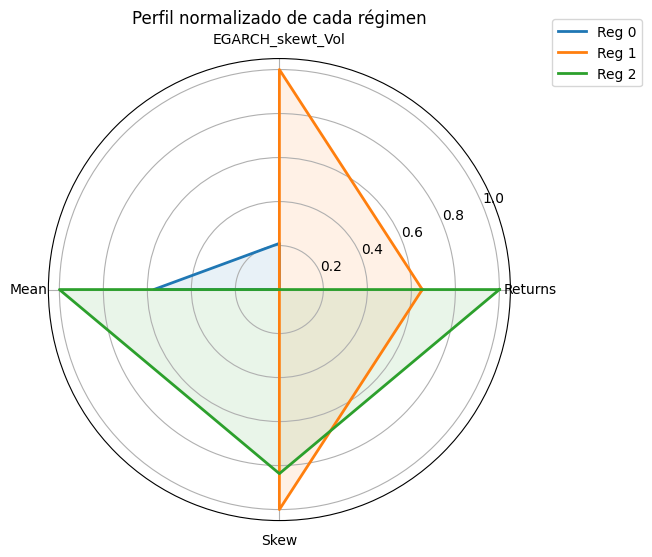

In [77]:
# 5. Radar / spider chart de las características promedio de cada régimen

from math import pi

features_radar = ['Returns', 'EGARCH_skewt_Vol', 'Mean', 'Skew']
means = df_plot.groupby('Regimen')[features_radar].mean()
# Normalizar para llevarlo a escala 0-1 (para el radar)
means_norm = (means - means.min()) / (means.max() - means.min())

categories = features_radar
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
for idx, row in means_norm.iterrows():
    values = row.values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=f'Reg {idx}')
    ax.fill(angles, values, alpha=0.1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_title('Perfil normalizado de cada régimen')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

| Reg            | EGARCH_Vol | Mean 20d | Returns | Skew | Interpretación |
|----------------|------------|----------|---------|------|----------------|
| Reg 1 (naranja) | 1.0 | 0.0 | 0.5 | 1.0 | Bajista/Crash: Vol máxima, Mean mínimo, Skew positiva = colas gordas hacia abajo |
| Reg 2 (verde)   | 0.0 | 1.0 | 1.0 | 0.8 | Alcista: Vol mínima, Mean y Returns máximos |
| Reg 0 (azul)    | 0.2 | 0.5 | 0.0 | 0.0 | Lateral/Boring: Vol baja, Returns mínimos, Skew negativa |

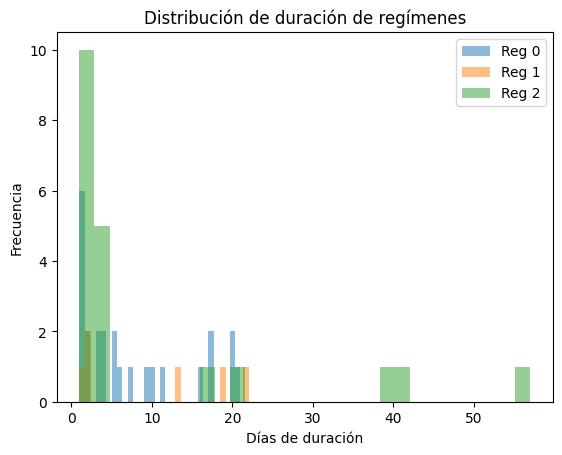

In [78]:
# Identificar rachas
df_plot['regime_change'] = (df_plot['Regimen'] != df_plot['Regimen'].shift(1)).astype(int)
df_plot['streak_id'] = df_plot['regime_change'].cumsum()
streaks = df_plot.groupby(['Regimen', 'streak_id']).size().reset_index(name='duration')

for r in sorted(df_plot['Regimen'].unique()):
    plt.hist(streaks.loc[streaks['Regimen']==r, 'duration'], bins=30, alpha=0.5, label=f'Reg {r}')
plt.legend()
plt.xlabel('Días de duración')
plt.ylabel('Frecuencia')
plt.title('Distribución de duración de regímenes')
plt.show()

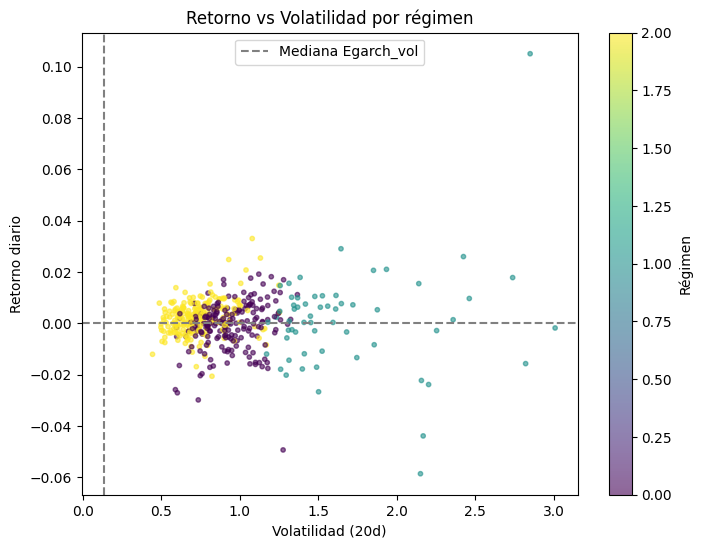

In [81]:
plt.figure(figsize=(8,6))
sc = plt.scatter(df_plot['EGARCH_skewt_Vol'], df_plot['Returns'], c=df_plot['Regimen'], cmap='viridis', s=10, alpha=0.6)
plt.colorbar(sc, label='Régimen')
plt.xlabel('Volatilidad (20d)')
plt.ylabel('Retorno diario')
plt.title('Retorno vs Volatilidad por régimen')
plt.axhline(0, color='gray', ls='--')
plt.axvline(df_plot['EGARCH_Vol'].median(), color='gray', ls='--', label='Mediana Egarch_vol')
plt.legend()
plt.show()

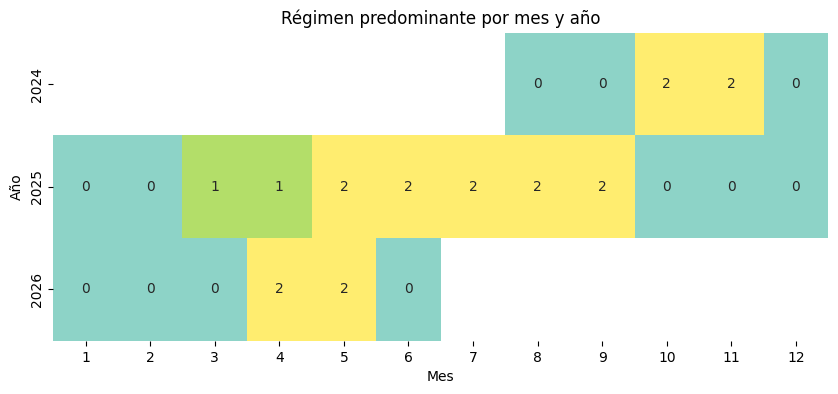

In [83]:
df_plot['year'] = df_plot.index.year
df_plot['month'] = df_plot.index.month
pivot = df_plot.pivot_table(index='year', columns='month', values='Regimen', aggfunc=lambda x: x.mode().iloc[0])

plt.figure(figsize=(10,4))
sns.heatmap(pivot, annot=True, cmap='Set3', cbar=False)
plt.title('Régimen predominante por mes y año')
plt.xlabel('Mes')
plt.ylabel('Año')
plt.show()

Text(0.5, 1.0, 'Regímenes detectados en SPY')

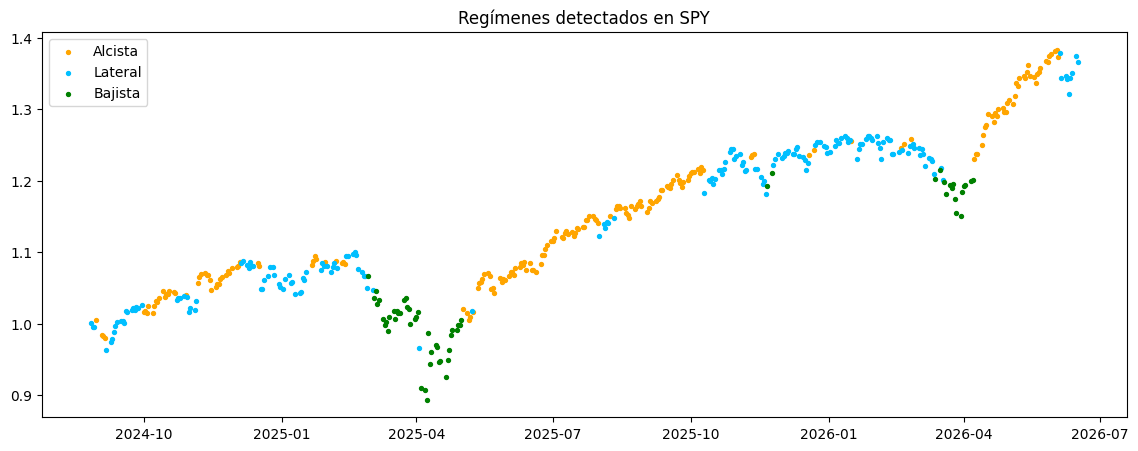

In [85]:
# Después del fit de KMeans
resumen = df_plot.groupby('Regimen')['Mean'].mean().sort_values()
mapa = {resumen.index[0]: 'Bajista',
        resumen.index[1]: 'Lateral',
        resumen.index[2]: 'Alcista'}
df_plot['Regimen_Nombre'] = df_plot['Regimen'].map(mapa)

# Ahora el plot con nombres y colores fijos
colores = {'Alcista': 'orange', 'Lateral': 'deepskyblue', 'Bajista': 'green'}
plt.figure(figsize=(14,5))
for nombre, color in colores.items():
    mask = df_plot['Regimen_Nombre'] == nombre
    plt.scatter(df_plot.index[mask], df_plot['Close'][mask], s=8, c=color, label=nombre)
plt.legend()
plt.title('Regímenes detectados en SPY')

In [88]:
# 1. Guarda el scaler 
scaler = StandardScaler().fit(X) # X 
X_scaled = scaler.transform(X)

# 2. Re-entrena KNN con X_scaled para que todo esté en la misma escala
knn = NearestNeighbors(n_neighbors=10)
knn.fit(X_scaled)

# 3. Para clasificar "hoy" o el último día de tu df
window = 20
ultimos_20 = df_plot['Returns'].iloc[-window:]

nueva_fila_features = [
    df_plot['Returns'].iloc[-1], # Return de hoy
    ultimos_20.std(), # Vol de 20d
    ultimos_20.mean(), # Mean de 20d
    ultimos_20.skew() # Skew de 20d
]

# 4. Escala con el mismo scaler y predice
nuevo_X = scaler.transform([nueva_fila_features])
dist, idx = knn.kneighbors(nuevo_X)
regimen_predicho = df_plot['Regimen_Nombre'].iloc[idx[0]].mode()[0]

print(f"Régimen predicho para hoy: {regimen_predicho}")
print(f"Basado en estos 10 días históricos: {df_plot.index[idx[0]].date}")

Régimen predicho para hoy: Lateral
Basado en estos 10 días históricos: [datetime.date(2026, 6, 16) datetime.date(2024, 9, 25)
 datetime.date(2024, 9, 18) datetime.date(2024, 9, 20)
 datetime.date(2024, 9, 27) datetime.date(2024, 8, 28)
 datetime.date(2025, 11, 6) datetime.date(2025, 12, 8)
 datetime.date(2024, 9, 17) datetime.date(2025, 11, 4)]


In [89]:
def clasificar_dia_actual(df, features, scaler, knn_model, window=20):
    ultimos = df_plot['Returns'].iloc[-window:]
    nueva_fila = [
        df_plot['Returns'].iloc[-1],
        ultimos.std(),
        ultimos.mean(),
        ultimos.skew()
    ]
    nuevo_X = scaler.transform([nueva_fila])
    _, idx = knn_model.kneighbors(nuevo_X)
    return df_plot['Regimen_Nombre'].iloc[idx[0]].mode()[0]

# Uso:
regimen_hoy = clasificar_dia_actual(df, features, scaler, knn)
print(regimen_hoy)

Lateral


# **Insolation Forest**

In [5]:
from arch import arch_model

df=ejecutar_analisis(ticker='SPY',periodo='5y')

df["Returns_Pct"] = df["Returns"] * 100
df_model = df["Returns_Pct"].dropna()

modelo_egarch_skewt = arch_model(
    df_model, mean="constant", vol="EGARCH",
    p=1, o=1, q=1, dist="skewt", rescale=False
)
res_skewt = modelo_egarch_skewt.fit(disp="off")

modelo_final = res_skewt
df["EGARCH_skewt_Vol"] = modelo_final.conditional_volatility

--- Procesando SPY para el periodo 5y ---


[*********************100%***********************]  1 of 1 completed


Regimen_IF
Normal    1187
Crisis      40
Spike        8
Name: count, dtype: int64

Fechas de Crisis:
DatetimeIndex(['2022-04-26', '2022-04-27', '2022-04-29', '2022-05-09',
               '2022-05-10', '2022-05-11', '2022-05-12', '2022-05-18',
               '2022-05-19', '2022-05-20'],
              dtype='datetime64[s]', name='Date', freq=None)


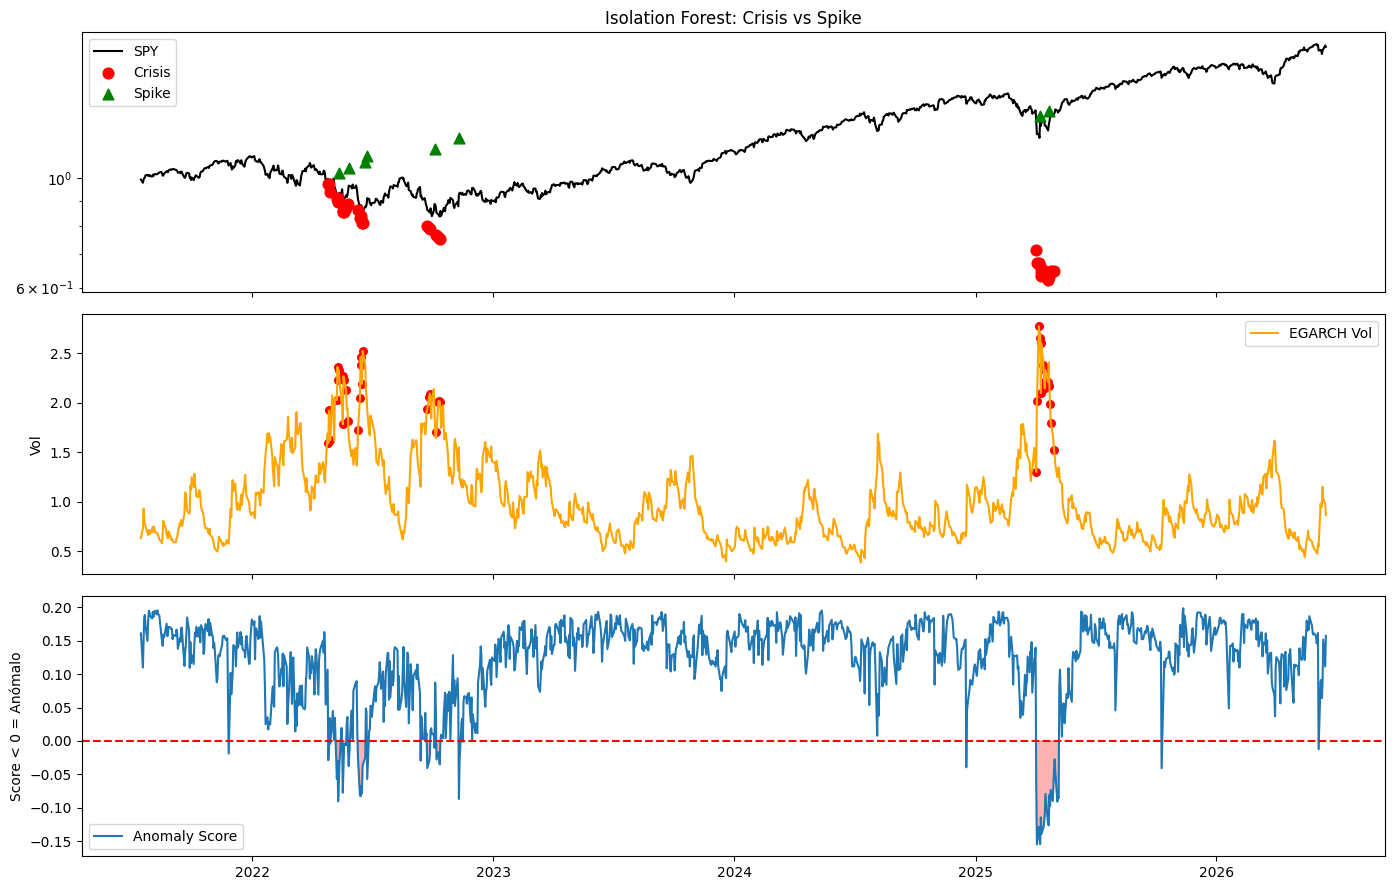

In [6]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import numpy as np

def regime_isolation_forest(df, contamination=0.05, window_feat=20):
    """
    contamination: % de días anómalos. 0.05 = 5% = ~1 día al mes
    """
    # 1. No borres las columnas que necesitas
    df = df[['Returns', 'EGARCH_skewt_Vol']].copy().dropna()
    
    # 2. Features
    df['Mean'] = df['Returns'].rolling(window_feat).mean()
    df['Skew'] = df['Returns'].rolling(window_feat).skew()
    df['Mom_5d'] = df['Returns'].rolling(5).sum()
    df['Vol_20d'] = df['Returns'].rolling(window_feat).std() * np.sqrt(252)
    df = df.dropna()
    
    features = ['Returns', 'EGARCH_skewt_Vol', 'Mean', 'Skew', 'Mom_5d', 'Vol_20d']
    X = df[features].values
    
    # 3. Estandariza: Isolation Forest es sensible a escala
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 4. Isolation Forest
    iso = IsolationForest(
        contamination=contamination,
        n_estimators=300,
        max_samples='auto',
        random_state=42,
        n_jobs=-1
    )
    df['Anomaly'] = iso.fit_predict(X_scaled) # -1 = anomalía, 1 = normal
    df['Anomaly_Score'] = iso.decision_function(X_scaled) # <0 = anómalo
    
    # 5. Clasifica anomalías en Crisis vs Spike
    df['Regimen_IF'] = 'Normal'
    # Crisis: anómalo + mean negativo + vol alta
    mask_crisis = (df['Anomaly'] == -1) & (df['Mean'] < 0) & (df['EGARCH_skewt_Vol'] > df['EGARCH_skewt_Vol'].quantile(0.8))
    df.loc[mask_crisis, 'Regimen_IF'] = 'Crisis'
    
    # Spike: anómalo + retorno positivo extremo
    mask_spike = (df['Anomaly'] == -1) & (df['Returns'] > df['Returns'].quantile(0.98))
    df.loc[mask_spike, 'Regimen_IF'] = 'Spike'
    
    return df, iso, scaler

# ---------------- USO ----------------
df_if, modelo_if, scaler_if = regime_isolation_forest(df, contamination=0.05)

print(df_if['Regimen_IF'].value_counts())
print("\nFechas de Crisis:")
print(df_if[df_if['Regimen_IF']=='Crisis'].index[:10])

# Plot
fig, ax = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
ax[0].plot(df_if.index, (1+df_if['Returns']).cumprod(), label='SPY', c='black')
crisis = df_if[df_if['Regimen_IF']=='Crisis']
spike = df_if[df_if['Regimen_IF']=='Spike']
ax[0].scatter(crisis.index, (1+df_if.loc[crisis.index, 'Returns']).cumprod(), 
              c='red', s=60, label='Crisis', zorder=5)
ax[0].scatter(spike.index, (1+df_if.loc[spike.index, 'Returns']).cumprod(), 
              c='green', s=60, marker='^', label='Spike', zorder=5)
ax[0].set_yscale('log')
ax[0].legend()
ax[0].set_title('Isolation Forest: Crisis vs Spike')

ax[1].plot(df_if.index, df_if['EGARCH_skewt_Vol'], label='EGARCH Vol', c='orange')
ax[1].scatter(crisis.index, df_if.loc[crisis.index, 'EGARCH_skewt_Vol'], c='red', s=30)
ax[1].set_ylabel('Vol')
ax[1].legend()

ax[2].plot(df_if.index, df_if['Anomaly_Score'], label='Anomaly Score')
ax[2].axhline(0, c='red', ls='--')
ax[2].fill_between(df_if.index, df_if['Anomaly_Score'], 0, 
                   where=df_if['Anomaly_Score']<0, alpha=0.3, color='red')
ax[2].set_ylabel('Score < 0 = Anómalo')
ax[2].legend()
plt.tight_layout()
plt.show()

In [7]:
# Caracteriza las anomalías en los dias de crisis vs dias normal
features = ['Returns', 'EGARCH_skewt_Vol', 'Mean', 'Skew', 'Mom_5d', 'Vol_20d']
crisis_stats = df_if[df_if['Regimen_IF']=='Crisis'][features].describe()
normal_stats = df_if[df_if['Regimen_IF']=='Normal'][features].describe()

print("Crisis vs Normal:")
print(pd.concat([crisis_stats.loc['mean'], normal_stats.loc['mean']], axis=1, 
               keys=['Crisis','Normal']).round(4))

Crisis vs Normal:
                  Crisis  Normal
Price                           
Returns          -0.0106  0.0007
EGARCH_skewt_Vol  2.0918  0.9513
Mean             -0.0038  0.0007
Skew              0.1405 -0.1065
Mom_5d           -0.0312  0.0037
Vol_20d           0.3548  0.1469


In [8]:
for n in [1, 5, 20, 63]: # 1 día, 1 semana, 1 mes, 3 meses
    df_if[f'Fwd_{n}d'] = df_if['Returns'].shift(-n).rolling(n).sum()

print("Retorno promedio después de Crisis:")
print(df_if[df_if['Regimen_IF']=='Crisis'][[f'Fwd_{n}d' for n in [1,5,20,63]]].mean())

print("\nRetorno promedio Normal:")
print(df_if[df_if['Regimen_IF']=='Normal'][[f'Fwd_{n}d' for n in [1,5,20,63]]].mean())

Retorno promedio después de Crisis:
Price
Fwd_1d     0.003203
Fwd_5d     0.020204
Fwd_20d    0.042482
Fwd_63d    0.105112
dtype: float64

Retorno promedio Normal:
Price
Fwd_1d     0.000505
Fwd_5d     0.002203
Fwd_20d    0.009715
Fwd_63d    0.028618
dtype: float64


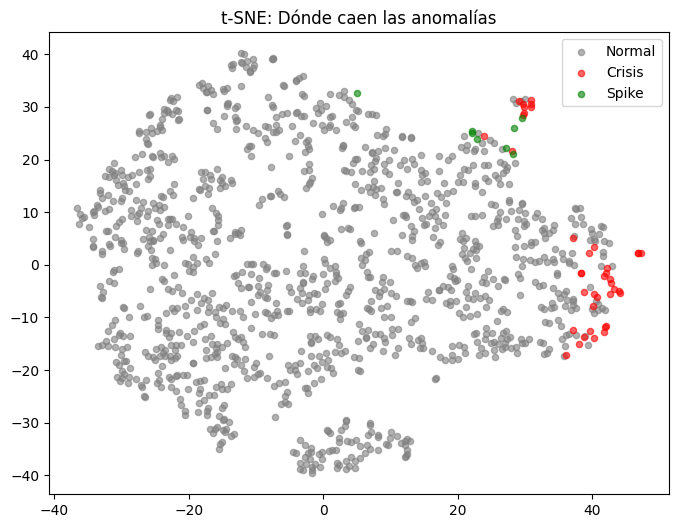

In [9]:
from sklearn.manifold import TSNE

# Overlay con t-SNE para ver clusters de anomalías

X = df_if[features].values
X_scaled = StandardScaler().fit_transform(X)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
coords = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8,6))
colors = {'Normal':'grey', 'Crisis':'red', 'Spike':'green'}
for regime, color in colors.items():
    mask = df_if['Regimen_IF'] == regime
    ax.scatter(coords[mask,0], coords[mask,1], c=color, label=regime, alpha=0.6, s=20)
ax.legend()
ax.set_title('t-SNE: Dónde caen las anomalías')
plt.show()

In [10]:
# Promedio de features cuando Anomaly_Score es mínimo vs máximo
df_if['Score_Q'] = pd.qcut(df_if['Anomaly_Score'], 5, labels=['Q1_MuyAnómalo','Q2','Q3','Q4','Q5_Normal'])
print(df_if.groupby('Score_Q')[features].mean().round(3))

Price          Returns  EGARCH_skewt_Vol   Mean   Skew  Mom_5d  Vol_20d
Score_Q                                                                
Q1_MuyAnómalo   -0.001             1.506 -0.001  0.046  -0.004    0.256
Q2               0.000             1.013  0.001 -0.109   0.002    0.155
Q3               0.000             0.888  0.001 -0.207   0.003    0.129
Q4               0.001             0.798  0.001 -0.096   0.006    0.117
Q5_Normal        0.002             0.774  0.001 -0.115   0.007    0.117


In [11]:
corr = df_if[['Anomaly_Score','EGARCH_skewt_Vol']].corr().iloc[0,1]
print(f"Corr Score vs EGARCH: {corr:.2f}") # seguro da -0.85

Corr Score vs EGARCH: -0.72


In [12]:
# Subtipo de Crisis
from sklearn.cluster import DBSCAN
coords_crisis = coords[df_if['Regimen_IF']=='Crisis']
db = DBSCAN(eps=5).fit(coords_crisis)
print("Sub-tipos de crisis:", np.unique(db.labels_))

df_if['Crisis_Subtipo'] = -2 # default = no crisis
df_if.loc[df_if['Regimen_IF']=='Crisis', 'Crisis_Subtipo'] = db.labels_

# Fechas de cada cluster
for label in [0, 1, -1]:
    fechas = df_if[df_if['Crisis_Subtipo']==label].index
    print(f"\nCluster {label}: {len(fechas)} días")
    print(fechas[:5]) # primeras 5 fechas

Sub-tipos de crisis: [-1  0  1]

Cluster 0: 27 días
DatetimeIndex(['2022-04-26', '2022-04-27', '2022-04-29', '2022-05-09',
               '2022-05-10'],
              dtype='datetime64[s]', name='Date', freq=None)

Cluster 1: 8 días
DatetimeIndex(['2025-04-11', '2025-04-14', '2025-04-15', '2025-04-17',
               '2025-04-23'],
              dtype='datetime64[s]', name='Date', freq=None)

Cluster -1: 5 días
DatetimeIndex(['2022-05-23', '2022-05-26', '2025-04-10', '2025-04-16',
               '2025-04-21'],
              dtype='datetime64[s]', name='Date', freq=None)


In [13]:
spikes = df_if[df_if['Regimen_IF']=='Spike']
for date in spikes.index:
    print(date, "Crisis anterior:", df_if.loc[:date][df_if['Regimen_IF']=='Crisis'].index[-1])

2022-05-13 00:00:00 Crisis anterior: 2022-05-12 00:00:00
2022-05-27 00:00:00 Crisis anterior: 2022-05-26 00:00:00
2022-06-21 00:00:00 Crisis anterior: 2022-06-17 00:00:00
2022-06-24 00:00:00 Crisis anterior: 2022-06-17 00:00:00
2022-10-04 00:00:00 Crisis anterior: 2022-09-27 00:00:00
2022-11-10 00:00:00 Crisis anterior: 2022-10-12 00:00:00
2025-04-09 00:00:00 Crisis anterior: 2025-04-08 00:00:00
2025-04-22 00:00:00 Crisis anterior: 2025-04-21 00:00:00


In [14]:
for n in [1,5,20,63]:
    df_if[f'Fwd_{n}d'] = df_if['Returns'].shift(-n).rolling(n).sum()

print("Retorno promedio post-evento:")
display(df_if.groupby('Regimen_IF')[[f'Fwd_{n}d' for n in [1,5,20,63]]].mean().round(4))

Retorno promedio post-evento:


Price,Fwd_1d,Fwd_5d,Fwd_20d,Fwd_63d
Regimen_IF,,,,
Crisis,0.0032,0.0202,0.0425,0.1051
Normal,0.0005,0.0022,0.0097,0.0286
Spike,-0.0045,-0.0114,0.0115,0.0559


Comprar en crisis nos da una rentabilidad luego en 3 meses de 10.51%

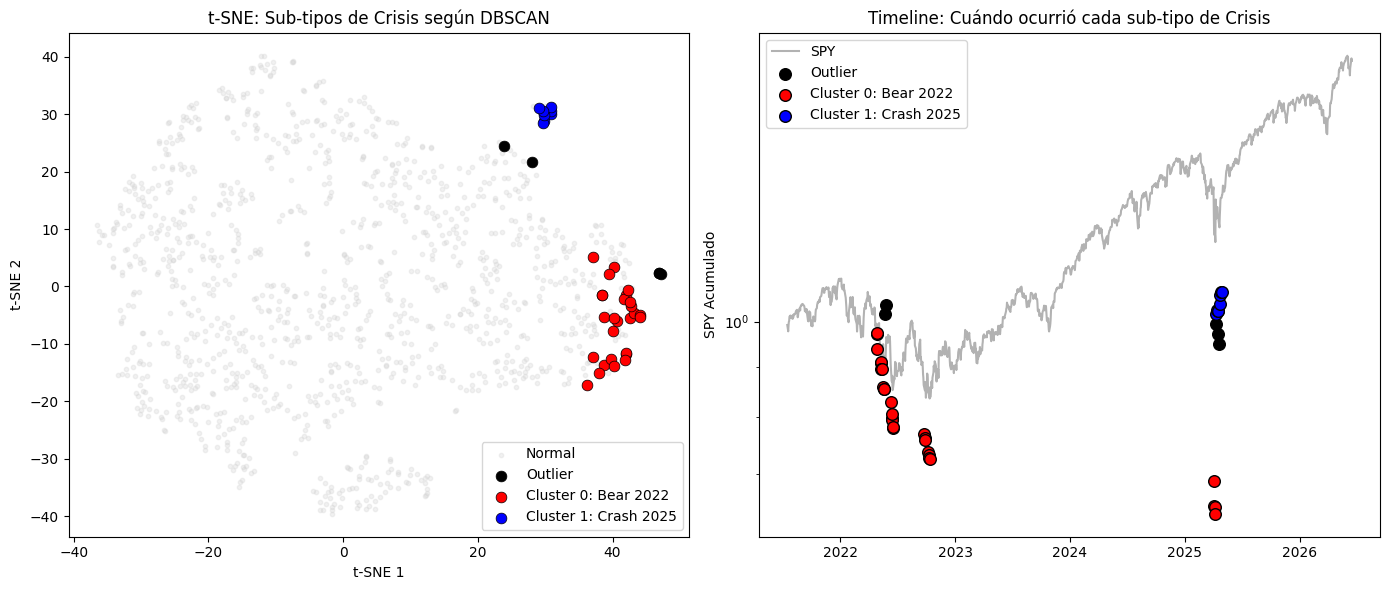

Conteo por sub-tipo:
Crisis_Subtipo
-2    1195
-1       5
 0      27
 1       8
Name: count, dtype: int64

Fechas ejemplo de cada cluster:
Outlier: [Timestamp('2022-05-23 00:00:00'), Timestamp('2022-05-26 00:00:00'), Timestamp('2025-04-10 00:00:00')]
Cluster 0: Bear 2022: [Timestamp('2022-04-26 00:00:00'), Timestamp('2022-04-27 00:00:00'), Timestamp('2022-04-29 00:00:00')]
Cluster 1: Crash 2025: [Timestamp('2025-04-11 00:00:00'), Timestamp('2025-04-14 00:00:00'), Timestamp('2025-04-15 00:00:00')]


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Asigna el subtipo a df_if
df_if['Crisis_Subtipo'] = -2 # -2 = No es crisis
mask_crisis = df_if['Regimen_IF'] == 'Crisis'
df_if.loc[mask_crisis, 'Crisis_Subtipo'] = db.labels_

# 2. Plot t-SNE solo de Crisis, coloreado por DBSCAN
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Todos los puntos + crisis coloreadas por subtipo
colors_subtipo = {-1: 'black', 0: 'red', 1: 'blue', 2: 'green'}
labels_subtipo = {-1: 'Outlier', 0: 'Cluster 0: Bear 2022', 1: 'Cluster 1: Crash 2025', 2: 'Cluster 2'}

# Fondo: todos los días normales en gris
mask_normal = df_if['Regimen_IF'] == 'Normal'
ax[0].scatter(coords[mask_normal, 0], coords[mask_normal, 1], 
              c='lightgrey', s=10, alpha=0.3, label='Normal')

# Encima: crisis por subtipo
for subtipo, color in colors_subtipo.items():
    mask = df_if['Crisis_Subtipo'] == subtipo
    if mask.sum() > 0:
        ax[0].scatter(coords[mask, 0], coords[mask, 1], 
                      c=color, s=60, label=labels_subtipo[subtipo], edgecolor='k', linewidth=0.5)

ax[0].set_title('t-SNE: Sub-tipos de Crisis según DBSCAN')
ax[0].legend(loc='best')
ax[0].set_xlabel('t-SNE 1')
ax[0].set_ylabel('t-SNE 2')

# Plot 2: Timeline de Crisis coloreado por subtipo
df_crisis = df_if[df_if['Regimen_IF'] == 'Crisis'].copy()
ax[1].plot(df_if.index, (1+df_if['Returns']).cumprod(), c='black', alpha=0.3, label='SPY')

for subtipo, color in colors_subtipo.items():
    mask = df_crisis['Crisis_Subtipo'] == subtipo
    if mask.sum() > 0:
        ax[1].scatter(df_crisis.index[mask], 
                      (1+df_if.loc[df_crisis.index[mask], 'Returns']).cumprod(),
                      c=color, s=70, label=labels_subtipo[subtipo], zorder=5, edgecolor='k')

ax[1].set_yscale('log')
ax[1].set_title('Timeline: Cuándo ocurrió cada sub-tipo de Crisis')
ax[1].legend()
ax[1].set_ylabel('SPY Acumulado')

plt.tight_layout()
plt.show()

# 3. Tabla resumen
print("Conteo por sub-tipo:")
print(df_if['Crisis_Subtipo'].value_counts().sort_index())
print("\nFechas ejemplo de cada cluster:")
for subtipo in sorted(df_if['Crisis_Subtipo'].unique()):
    if subtipo >= -1:
        fechas = df_if[df_if['Crisis_Subtipo']==subtipo].index
        print(f"{labels_subtipo[subtipo]}: {list(fechas[:3])}")

In [16]:
df_if['Crisis_Subtipo'] = -2
df_if.loc[mask_crisis, 'Crisis_Subtipo'] = db.labels_

for n in [5, 20, 63]:
    df_if[f'Fwd_{n}d'] = df_if['Returns'].shift(-n).rolling(n).sum()

res = df_if[df_if['Regimen_IF']=='Crisis'].groupby('Crisis_Subtipo')[
    ['Fwd_5d','Fwd_20d','Fwd_63d']].agg(['mean','count'])
print(res.round(4))

Price           Fwd_5d       Fwd_20d       Fwd_63d      
                  mean count    mean count    mean count
Crisis_Subtipo                                          
-1              0.0336     5  0.0512     5  0.1264     5
 0              0.0207    27  0.0291    27  0.0851    27
 1              0.0102     8  0.0821     8  0.1594     8


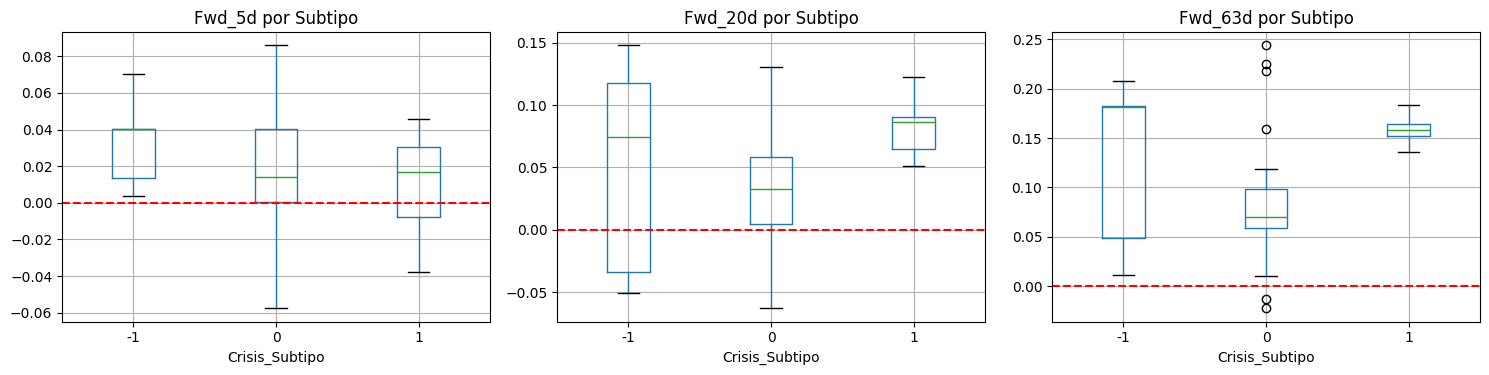

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for i, days in enumerate([5, 20, 63]):
    df_if[df_if['Regimen_IF']=='Crisis'].boxplot(
        column=f'Fwd_{days}d', by='Crisis_Subtipo', ax=ax[i]
    )
    ax[i].set_title(f'Fwd_{days}d por Subtipo')
    ax[i].axhline(0, c='r', ls='--')
plt.suptitle('')
plt.tight_layout()
plt.show()